# ATLAS Results Analysis
**Date:** March 2026  
**Models tested:** DistilBERT, GPT-2, Qwen-2.5-0.5B  
**Methods:** ATLAS (full), ATLAS (no Laplacian)†, Standard FedAvg, FedAvg-Cluster†  
**Tasks:** SST-2, MRPC, QNLI  
**Seeds:** 42, 123, 456 | **Rounds:** 10  
† Ablation/cluster methods available for GPT-2 only


In [33]:
import json, os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

# ── IEEE Transactions Publication Style ──────────────────────────────────────
IEEE_RC = {
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Bitstream Vera Serif'],
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 7.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'lines.linewidth': 1.5,
    'lines.markersize': 5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'grid.linewidth': 0.5,
    'legend.frameon': True,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
}
plt.rcParams.update(IEEE_RC)

# Resolve results dir relative to this notebook's working directory
RESULTS_DIR = os.path.abspath(os.path.join(os.getcwd(), 'results'))

# IEEE figure widths (inches)
IEEE_2COL = 7.16    # double-column figure
IEEE_1COL = 3.54    # single-column figure

# ── Colour palette (colour-blind safe, high contrast) ────────────────────────
METHOD_COLORS = {
    'atlas':              '#1565C0',   # dark blue
    'atlas_no_laplacian': '#E65100',   # deep orange
    'fedavg_cluster':     '#2E7D32',   # dark green
    'standard_fl':        '#C62828',   # dark red
}
METHOD_LABELS = {
    'atlas':              'ATLAS',
    'atlas_no_laplacian': 'ATLAS w/o Laplacian',
    'fedavg_cluster':     'FedAvg-Cluster',
    'standard_fl':        'Standard FedAvg',
}
METHOD_HATCHES = {
    'atlas':              '',
    'atlas_no_laplacian': '//',
    'fedavg_cluster':     'xx',
    'standard_fl':        '\\\\',
}
METHOD_MARKERS = {
    'atlas':              'o',
    'atlas_no_laplacian': 's',
    'fedavg_cluster':     '^',
    'standard_fl':        'D',
}

# Model configuration
MODEL_ORDER   = ['DistilBERT', 'GPT-2', 'Qwen-2.5']
MODEL_LABELS  = {'DistilBERT': 'DistilBERT', 'GPT-2': 'GPT-2', 'Qwen-2.5': 'Qwen-2.5-0.5B'}
# Which methods are shown per model (GPT-2 gets full ablation)
MODEL_METHODS = {
    'DistilBERT': ['standard_fl', 'atlas'],
    'GPT-2':      ['standard_fl', 'fedavg_cluster', 'atlas_no_laplacian', 'atlas'],
    'Qwen-2.5':   ['standard_fl', 'atlas'],
}
ABLATION_ONLY_MODELS = {'GPT-2'}   # only GPT-2 has no_laplacian / fedavg_cluster

# Client → task mapping (9 clients, 3 tasks × 3 clients)
TASK_MAP = {0:'SST-2', 1:'SST-2', 2:'SST-2',
            3:'MRPC',  4:'MRPC',  5:'MRPC',
            6:'QNLI',  7:'QNLI',  8:'QNLI'}
FAIL_THRESH = 0.65   # per-client accuracy below this = "client failure"

# Cluster colours for clustering figure
CLUSTER_COLORS = {0: '#E53935', 1: '#43A047', 2: '#1E88E5'}
CLUSTER_NAMES  = {0: 'Cluster 0\n(SST-2)', 1: 'Cluster 1\n(MRPC)', 2: 'Cluster 2\n(QNLI)'}
DEVICE_MARKERS = {'cpu_2gb': 'o', 'tablet_4gb': 's', 'laptop_8gb': '^', 'gpu_16gb': 'D'}

print(f'Libraries loaded ✓  |  IEEE style active ✓')
print(f'RESULTS_DIR = {RESULTS_DIR}')
print(f'Results dir exists: {os.path.isdir(RESULTS_DIR)}')


Libraries loaded ✓  |  IEEE style active ✓
RESULTS_DIR = c:\Users\Hp\Downloads\Advanced_project\ATLAS\results
Results dir exists: True


In [ ]:

# ── Load all result files ─────────────────────────────────────────────────────
def load_results(results_dir):
    records = []
    TASK_JSON_KEY = {'SST-2': 'sst2', 'MRPC': 'mrpc', 'QNLI': 'qnli'}

    for fpath in sorted(glob.glob(f'{results_dir}/*.json')):
        fname = os.path.basename(fpath).replace('.json', '')

        with open(fpath) as f:
            d = json.load(f)

        rm   = d.get('run_metadata', {})
        mode = rm.get('ablation_mode', 'unknown')

        # Detect model from filename (case-insensitive)
        fl = fname.lower()
        if 'distilbert' in fl:
            model = 'DistilBERT'
        elif 'gpt2' in fl:
            model = 'GPT-2'
        elif 'qwen' in fl:
            model = 'Qwen-2.5'
        else:
            model = 'Unknown'

        # Extract seed from filename  (e.g. _seed42_)
        seed = None
        for part in fname.split('_'):
            if part.startswith('seed'):
                try:
                    seed = int(part.replace('seed', ''))
                except ValueError:
                    pass

        # Per-client final accuracy / f1
        final_acc = d.get('final_accuracies', {})
        if not isinstance(final_acc, dict):
            final_acc = {}
        final_f1  = d.get('final_f1', {})
        if not isinstance(final_f1, dict):
            final_f1 = {}
        final_ppl = d.get('final_ppl', {})
        if not isinstance(final_ppl, dict):
            final_ppl = {}
        weak_device_dropped = d.get('weak_device_dropped', {})
        if not isinstance(weak_device_dropped, dict):
            weak_device_dropped = {}

        # Per-task scores — read directly from final_task_scores (uses the
        # correct metric per task: accuracy for SST-2/QNLI, F1 for MRPC)
        json_task_scores = d.get('final_task_scores', {})
        task_score, task_ppl = {}, {}
        for task in ['SST-2', 'MRPC', 'QNLI']:
            jkey = TASK_JSON_KEY[task]
            if jkey in json_task_scores:
                task_score[task] = json_task_scores[jkey].get('mean', np.nan)
            else:
                # fallback: average final_accuracies for this task's clients
                clients = [k for k, v in TASK_MAP.items() if v == task]
                task_score[task] = np.mean([final_acc.get(str(c), np.nan) for c in clients])
            clients = [k for k, v in TASK_MAP.items() if v == task]
            task_ppl[task] = np.mean([final_ppl.get(str(c), np.nan) for c in clients])

        # Weak-device clients dropped (count of unique client IDs, not threshold calc)
        n_fail = len(weak_device_dropped)

        all_accs = [final_acc.get(str(c), np.nan) for c in range(9)]

        records.append({
            'file': fname,
            'model': model,
            'method': mode,
            'seed': seed,
            'macro_acc': d.get('macro_avg_canonical', np.nan),
            'personalization_spread': d.get('personalization_spread', np.nan),
            'lora_comm_mb': d.get('lora_weight_comm_mb', np.nan),
            'total_comm_mb': d.get('total_comm_mb', np.nan),
            'acc_sst2': task_score['SST-2'],
            'acc_mrpc': task_score['MRPC'],
            'acc_qnli': task_score['QNLI'],
            'f1_sst2':  task_score['SST-2'],
            'f1_mrpc':  task_score['MRPC'],
            'f1_qnli':  task_score['QNLI'],
            'n_failing_clients': n_fail,
            'weak_device_dropped': weak_device_dropped,
            'per_client_acc': all_accs,
            'round_metrics': d.get('round_metrics', []),
            'final_accuracies': final_acc,
            'final_f1': final_f1,
            'final_ppl': final_ppl,
            'cluster_labels': d.get('cluster_labels', {}),
            'fingerprints': d.get('fingerprints', {}),
            'phase2_rank_allocation': d.get('phase2_rank_allocation', []),
            'clustering_metrics': d.get('clustering_metrics', {}),
        })
    return pd.DataFrame(records)

df = load_results(RESULTS_DIR)

# Filter to known models only; drop 'Unknown' entries
df = df[df['model'] != 'Unknown'].copy()

print(f'Loaded {len(df)} experiment runs\n')
summary_counts = df.groupby(['model', 'method'])['seed'].count().reset_index()
summary_counts.columns = ['Model', 'Method', 'N Seeds']
print(summary_counts.to_string(index=False))
print()
df[['model', 'method', 'seed', 'macro_acc', 'n_failing_clients',
    'personalization_spread', 'lora_comm_mb']].sort_values(
    ['model', 'method', 'seed']).reset_index(drop=True)


Loaded 24 experiment runs

     Model             Method  N Seeds
DistilBERT              atlas        3
DistilBERT        standard_fl        3
     GPT-2              atlas        3
     GPT-2 atlas_no_laplacian        3
     GPT-2     fedavg_cluster        3
     GPT-2        standard_fl        3
  Qwen-2.5              atlas        3
  Qwen-2.5        standard_fl        3



,model,method,seed,macro_acc,n_failing_clients,personalization_spread,lora_comm_mb
0,DistilBERT,atlas,42,0.784194,0,0.067482,611.36016
1,DistilBERT,atlas,123,0.775005,0,0.080804,611.36016
2,DistilBERT,atlas,456,0.790410,0,0.050310,611.36016
3,DistilBERT,standard_fl,42,0.607250,2,0.143391,889.31664
4,DistilBERT,standard_fl,123,0.625742,2,0.137187,889.31664
5,DistilBERT,standard_fl,456,0.631183,2,0.112400,889.31664
6,GPT-2,atlas,42,0.809467,0,0.092195,587.45344
7,GPT-2,atlas,123,0.824236,0,0.072387,479.29088
8,GPT-2,atlas,456,0.792565,0,0.079220,597.28640
9,GPT-2,atlas_no_laplacian,42,0.787808,0,0.104869,587.45344


---
## 1  Summary Table — Mean ± Std across Seeds

In [35]:
# ── Aggregate over seeds ──────────────────────────────────────────────────────
agg_cols = ['macro_acc', 'acc_sst2', 'acc_mrpc', 'acc_qnli',
            'f1_sst2', 'f1_mrpc', 'f1_qnli',
            'personalization_spread', 'lora_comm_mb', 'n_failing_clients']

grouped = df.groupby(['model', 'method'])[agg_cols]
summary = grouped.agg(['mean', 'std']).round(4)
summary.columns = [f'{c}_{s}' for c, s in summary.columns]
summary = summary.reset_index()
n_seeds = df.groupby(['model', 'method'])['seed'].count().reset_index()
n_seeds.columns = ['model', 'method', 'n_seeds']
summary = summary.merge(n_seeds, on=['model', 'method'])

# Pretty display — ordered by MODEL_ORDER
model_order_map = {m: i for i, m in enumerate(MODEL_ORDER)}
summary['_sort'] = summary['model'].map(model_order_map)
summary = summary.sort_values(['_sort', 'method']).drop('_sort', axis=1).reset_index(drop=True)

display_cols = ['model', 'method', 'n_seeds',
                'macro_acc_mean', 'macro_acc_std',
                'acc_sst2_mean', 'acc_mrpc_mean', 'acc_qnli_mean',
                'personalization_spread_mean',
                'n_failing_clients_mean', 'lora_comm_mb_mean']

display_df = summary[display_cols].copy()
display_df.columns = ['Model', 'Method', 'Seeds',
                      'Macro Acc (mean)', 'Macro Acc (std)',
                      'SST-2', 'MRPC (F1)', 'QNLI',
                      'Person. Spread', 'Weak Devs Dropped', 'LoRA Comm (MB)']

def highlight_max(s): return ['font-weight:bold;color:#1565C0' if v else '' for v in s==s.max()]
def highlight_min(s): return ['font-weight:bold;color:#B71C1C' if v else '' for v in s==s.min()]

styled = (display_df.style
    .format({c: '{:.4f}' for c in ['Macro Acc (mean)', 'Macro Acc (std)',
                                    'SST-2', 'MRPC (F1)', 'QNLI', 'Person. Spread']})
    .format({'Weak Devs Dropped': '{:.0f}', 'LoRA Comm (MB)': '{:,.1f}', 'Seeds': '{:.0f}'})
    .apply(highlight_max, subset=['Macro Acc (mean)', 'SST-2', 'MRPC (F1)', 'QNLI'])
    .apply(highlight_min, subset=['Person. Spread', 'Weak Devs Dropped', 'LoRA Comm (MB)'])
    .set_caption('Table 1 – Summary (mean ± std over seeds) — Weak Devs Dropped: # clients in weak_device_dropped')
    .set_properties(**{'border': '1px solid #ddd', 'padding': '5px'})
)
display(styled)

# LaTeX rows
print('\n=== LaTeX rows ===')
for _, row in display_df.iterrows():
    m_row = summary.loc[(summary['Model']==row['Model']) & (summary['Method']==row['Method'])] \
               if 'Model' in summary.columns else \
               summary.loc[(summary['model']==row['Model']) & (summary['method']==row['Method'])]
    # simpler lookup
    mask = (summary['model']==row['Model']) & (summary['method']==row['Method'])
    std_ = summary.loc[mask, 'macro_acc_std'].values
    std_s = f'{std_[0]:.4f}' if len(std_) else 'N/A'
    print(f"{row['Model']} & {METHOD_LABELS.get(row['Method'], row['Method'])} & "
          f"{row['Seeds']:.0f} & "
          f"{row['Macro Acc (mean)']:.4f}$\\pm${std_s} & "
          f"{row['SST-2']:.4f} & {row['MRPC (F1)']:.4f} & {row['QNLI']:.4f} & "
          f"{row['Weak Devs Dropped']:.0f} & "
          f"{row['LoRA Comm (MB)']:,.1f} \\\\")


,Model,Method,Seeds,Macro Acc (mean),Macro Acc (std),SST-2,MRPC (F1),QNLI,Person. Spread,Weak Devs Dropped,LoRA Comm (MB)
0,DistilBERT,atlas,3,0.783200,0.007800,0.865400,0.729800,0.754400,0.066200,0,611.4
1,DistilBERT,standard_fl,3,0.621400,0.012500,0.670500,0.442300,0.651400,0.131000,2,889.3
2,GPT-2,atlas,3,0.808800,0.015800,0.897000,0.745100,0.815600,0.081300,0,554.7
3,GPT-2,atlas_no_laplacian,3,0.788100,0.000200,0.823700,0.654800,0.745600,0.104900,0,587.5
4,GPT-2,fedavg_cluster,3,0.696200,0.001600,0.635800,0.604600,0.695800,0.124900,2,685.8
5,GPT-2,standard_fl,3,0.560500,0.007100,0.685800,0.462300,0.533500,0.098900,2,827.4
6,Qwen-2.5,atlas,3,0.856800,0.005400,0.903300,0.802300,0.875400,0.034400,0,"1,154.0"
7,Qwen-2.5,standard_fl,3,0.788200,0.024700,0.829500,0.723400,0.822300,0.059600,2,"4,070.9"



=== LaTeX rows ===
DistilBERT & ATLAS & 3 & 0.7832$\pm$0.0078 & 0.8654 & 0.7298 & 0.7544 & 0 & 611.4 \\
DistilBERT & Standard FedAvg & 3 & 0.6214$\pm$0.0125 & 0.6705 & 0.4423 & 0.6514 & 2 & 889.3 \\
GPT-2 & ATLAS & 3 & 0.8088$\pm$0.0158 & 0.8970 & 0.7451 & 0.8156 & 0 & 554.7 \\
GPT-2 & ATLAS w/o Laplacian & 3 & 0.7881$\pm$0.0002 & 0.8237 & 0.6548 & 0.7456 & 0 & 587.5 \\
GPT-2 & FedAvg-Cluster & 3 & 0.6962$\pm$0.0016 & 0.6358 & 0.6046 & 0.6958 & 2 & 685.8 \\
GPT-2 & Standard FedAvg & 3 & 0.5605$\pm$0.0071 & 0.6858 & 0.4623 & 0.5335 & 2 & 827.4 \\
Qwen-2.5 & ATLAS & 3 & 0.8568$\pm$0.0054 & 0.9033 & 0.8023 & 0.8754 & 0 & 1,154.0 \\
Qwen-2.5 & Standard FedAvg & 3 & 0.7882$\pm$0.0247 & 0.8295 & 0.7234 & 0.8223 & 2 & 4,070.9 \\


---
## 2  ATLAS Improvement over Baselines

In [36]:
print('=' * 70)
print('  ATLAS vs Standard FedAvg — Improvement (mean across seeds)')
print('=' * 70)

for model in MODEL_ORDER:
    sub = summary[summary['model'] == model]
    if sub.empty:
        continue
    atlas_row  = sub[sub['method'] == 'atlas']
    std_fl_row = sub[sub['method'] == 'standard_fl']
    if atlas_row.empty or std_fl_row.empty:
        continue
    delta_acc  = atlas_row['macro_acc_mean'].values[0] - std_fl_row['macro_acc_mean'].values[0]
    delta_sst2 = atlas_row['acc_sst2_mean'].values[0]  - std_fl_row['acc_sst2_mean'].values[0]
    delta_mrpc = atlas_row['acc_mrpc_mean'].values[0]  - std_fl_row['acc_mrpc_mean'].values[0]
    delta_qnli = atlas_row['acc_qnli_mean'].values[0]  - std_fl_row['acc_qnli_mean'].values[0]
    delta_pers = atlas_row['personalization_spread_mean'].values[0] - std_fl_row['personalization_spread_mean'].values[0]
    weak_atlas = atlas_row['n_failing_clients_mean'].values[0]
    weak_std   = std_fl_row['n_failing_clients_mean'].values[0]
    n_s_atlas  = atlas_row['n_seeds'].values[0]
    n_s_std    = std_fl_row['n_seeds'].values[0]
    print(f'\n  [{model}]  (ATLAS: {n_s_atlas} seeds | StdFL: {n_s_std} seeds)')
    print(f'    Macro Acc gain           : {delta_acc:+.4f}  ({delta_acc*100:+.2f}%)')
    print(f'    SST-2 Acc gain           : {delta_sst2:+.4f}')
    print(f'    MRPC F1 gain             : {delta_mrpc:+.4f}')
    print(f'    QNLI Acc gain            : {delta_qnli:+.4f}')
    print(f'    Person. Spread Δ         : {delta_pers:+.4f}  (< 0 = ATLAS more uniform)')
    print(f'    Weak devs dropped (ATLAS): {weak_atlas:.0f}  |  StdFL: {weak_std:.0f}')

print('\n  [GPT-2 only] Ablation: ATLAS vs ATLAS w/o Laplacian')
sub = summary[summary['model'] == 'GPT-2']
atlas_row = sub[sub['method'] == 'atlas']
noLap_row = sub[sub['method'] == 'atlas_no_laplacian']
if not atlas_row.empty and not noLap_row.empty:
    d = atlas_row['macro_acc_mean'].values[0] - noLap_row['macro_acc_mean'].values[0]
    print(f'    Laplacian contribution: {d:+.4f} macro acc')


  ATLAS vs Standard FedAvg — Improvement (mean across seeds)

  [DistilBERT]  (ATLAS: 3 seeds | StdFL: 3 seeds)
    Macro Acc gain           : +0.1618  (+16.18%)
    SST-2 Acc gain           : +0.1949
    MRPC F1 gain             : +0.2875
    QNLI Acc gain            : +0.1030
    Person. Spread Δ         : -0.0648  (< 0 = ATLAS more uniform)
    Weak devs dropped (ATLAS): 0  |  StdFL: 2

  [GPT-2]  (ATLAS: 3 seeds | StdFL: 3 seeds)
    Macro Acc gain           : +0.2483  (+24.83%)
    SST-2 Acc gain           : +0.2112
    MRPC F1 gain             : +0.2828
    QNLI Acc gain            : +0.2821
    Person. Spread Δ         : -0.0176  (< 0 = ATLAS more uniform)
    Weak devs dropped (ATLAS): 0  |  StdFL: 2

  [Qwen-2.5]  (ATLAS: 3 seeds | StdFL: 3 seeds)
    Macro Acc gain           : +0.0686  (+6.86%)
    SST-2 Acc gain           : +0.0738
    MRPC F1 gain             : +0.0789
    QNLI Acc gain            : +0.0531
    Person. Spread Δ         : -0.0252  (< 0 = ATLAS more uniform)


---
## 3  Bar Chart — Macro Accuracy per Method × Model

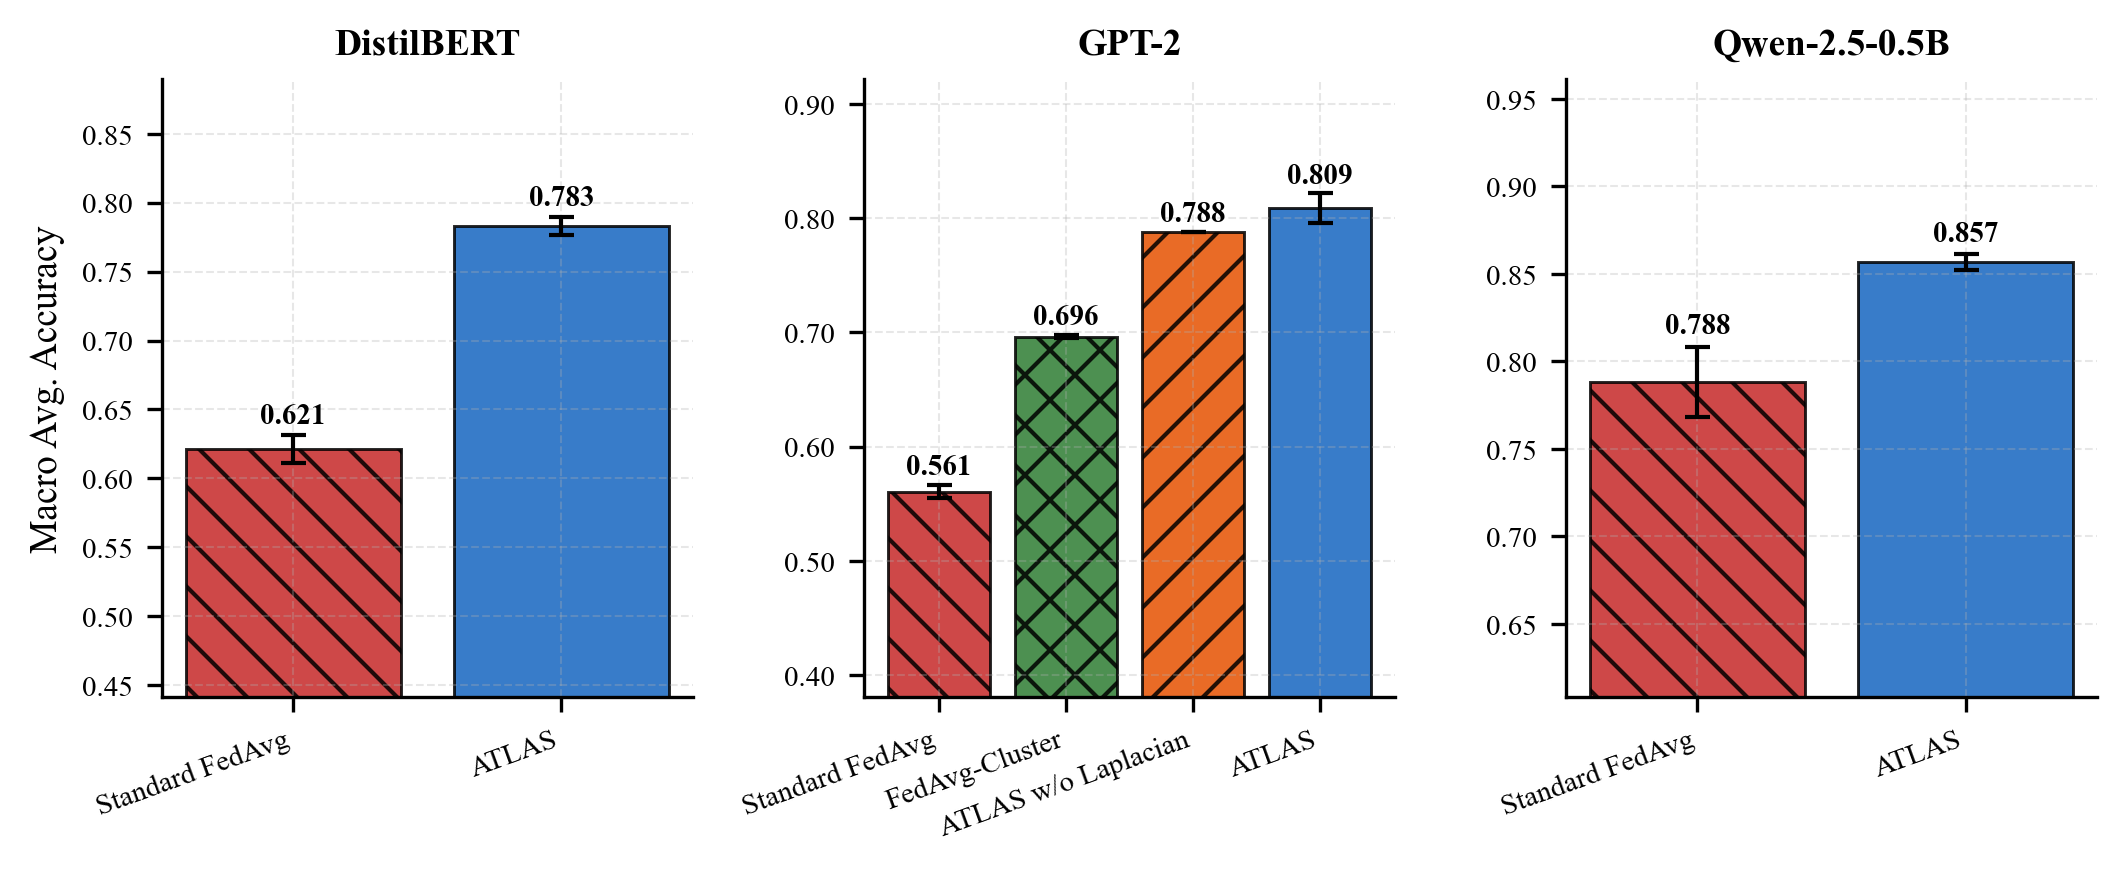

Saved fig1_macro_accuracy.pdf


In [37]:
# ── Fig. 1: Macro Accuracy per Method × Model (IEEE 3-panel) ─────────────────
models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]
n_models = len(models_present)

fig, axes = plt.subplots(1, n_models, figsize=(IEEE_2COL, 3.2), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models_present):
    sub = df[df['model'] == model]
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas'])
               if m in sub['method'].unique()]

    means  = [sub[sub['method'] == m]['macro_acc'].mean() for m in methods]
    stds   = [sub[sub['method'] == m]['macro_acc'].std(ddof=0) for m in methods]
    colors = [METHOD_COLORS[m] for m in methods]
    hatch  = [METHOD_HATCHES[m] for m in methods]
    xlabs  = [METHOD_LABELS[m] for m in methods]
    x      = np.arange(len(methods))

    bars = ax.bar(x, means, yerr=stds, capsize=3,
                  color=colors, hatch=hatch, alpha=0.85,
                  edgecolor='black', linewidth=0.7,
                  error_kw={'ecolor': 'black', 'elinewidth': 1.0, 'capthick': 1.0})

    for bar, mv, sv in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + sv + 0.004,
                f'{mv:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(xlabs, fontsize=7, rotation=20, ha='right')
    ax.set_ylabel('Macro Avg. Accuracy' if ax == axes[0] else '')
    ax.set_title(MODEL_LABELS[model], fontweight='bold', fontsize=9)
    ylo = max(0, min(means) - 0.18)
    yhi = min(1.0, max(m + s for m, s in zip(means, stds)) + 0.10)
    ax.set_ylim(ylo, yhi)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(f'{RESULTS_DIR}/fig1_macro_accuracy.pdf', bbox_inches='tight')
plt.show()
print('Saved fig1_macro_accuracy.pdf')


---
## 4  Per-Task Accuracy — Grouped Bar Chart

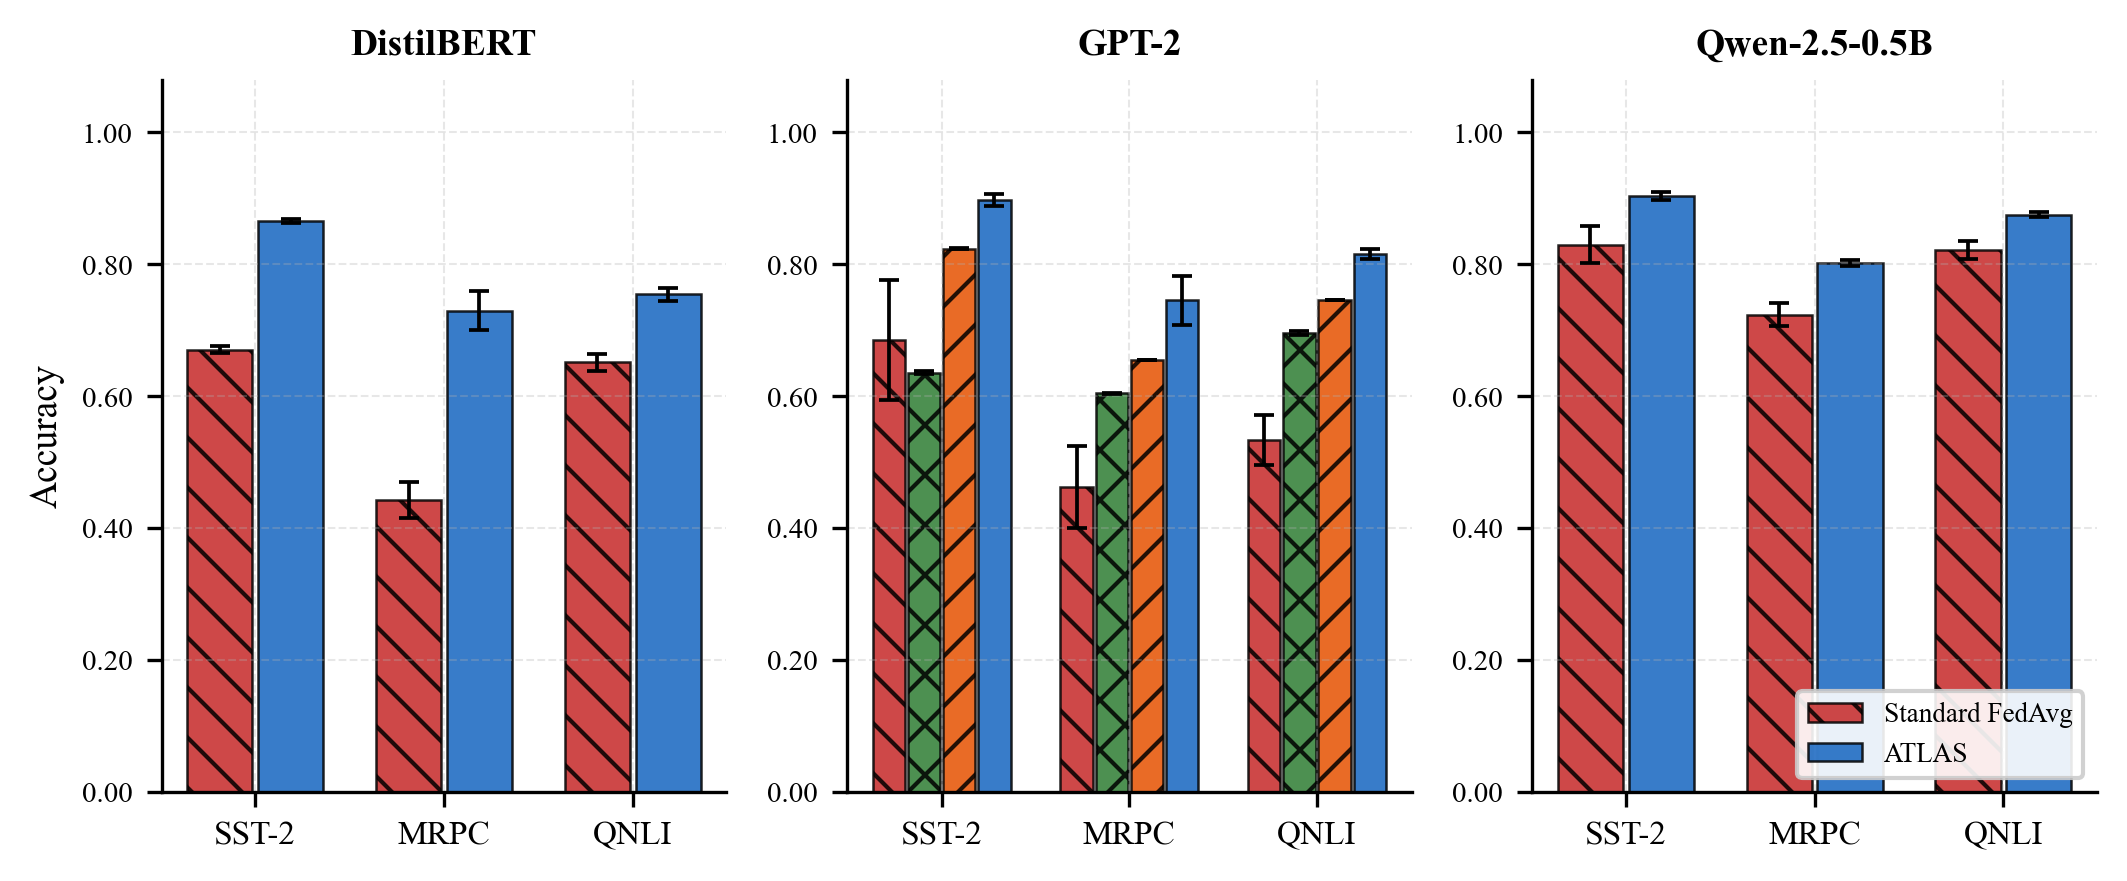

Saved fig2_per_task_accuracy.pdf


In [38]:
# ── Fig. 2: Per-Task Accuracy — Grouped Bar Chart (IEEE 3-panel) ─────────────
tasks     = ['SST-2', 'MRPC', 'QNLI']
task_cols = {'SST-2': 'acc_sst2', 'MRPC': 'acc_mrpc', 'QNLI': 'acc_qnli'}

models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]
n_models = len(models_present)

fig, axes = plt.subplots(1, n_models, figsize=(IEEE_2COL, 3.2), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models_present):
    sub     = df[df['model'] == model]
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas'])
               if m in sub['method'].unique()]

    n_m = len(methods)
    n_t = len(tasks)
    x   = np.arange(n_t)
    w   = 0.75 / n_m
    offsets = np.linspace(-(n_m - 1) / 2, (n_m - 1) / 2, n_m) * w

    for method, offset in zip(methods, offsets):
        sub_m = sub[sub['method'] == method]
        means = [sub_m[task_cols[t]].mean() for t in tasks]
        stds  = [sub_m[task_cols[t]].std(ddof=0) for t in tasks]
        ax.bar(x + offset, means, w * 0.92, yerr=stds, capsize=2.5,
               label=METHOD_LABELS[method],
               color=METHOD_COLORS[method], hatch=METHOD_HATCHES[method],
               alpha=0.85, edgecolor='black', linewidth=0.6,
               error_kw={'ecolor': 'black', 'elinewidth': 0.9, 'capthick': 0.9})

    ax.set_xticks(x)
    ax.set_xticklabels(tasks, fontsize=8)
    ax.set_ylabel('Accuracy' if ax == axes[0] else '')
    ax.set_title(MODEL_LABELS[model], fontweight='bold', fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='y', labelsize=7)
    if model == models_present[-1]:
        ax.legend(fontsize=6.5, loc='lower right', ncol=1)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f'{RESULTS_DIR}/fig2_per_task_accuracy.pdf', bbox_inches='tight')
plt.show()
print('Saved fig2_per_task_accuracy.pdf')


---
## 5  Convergence — Accuracy over Rounds

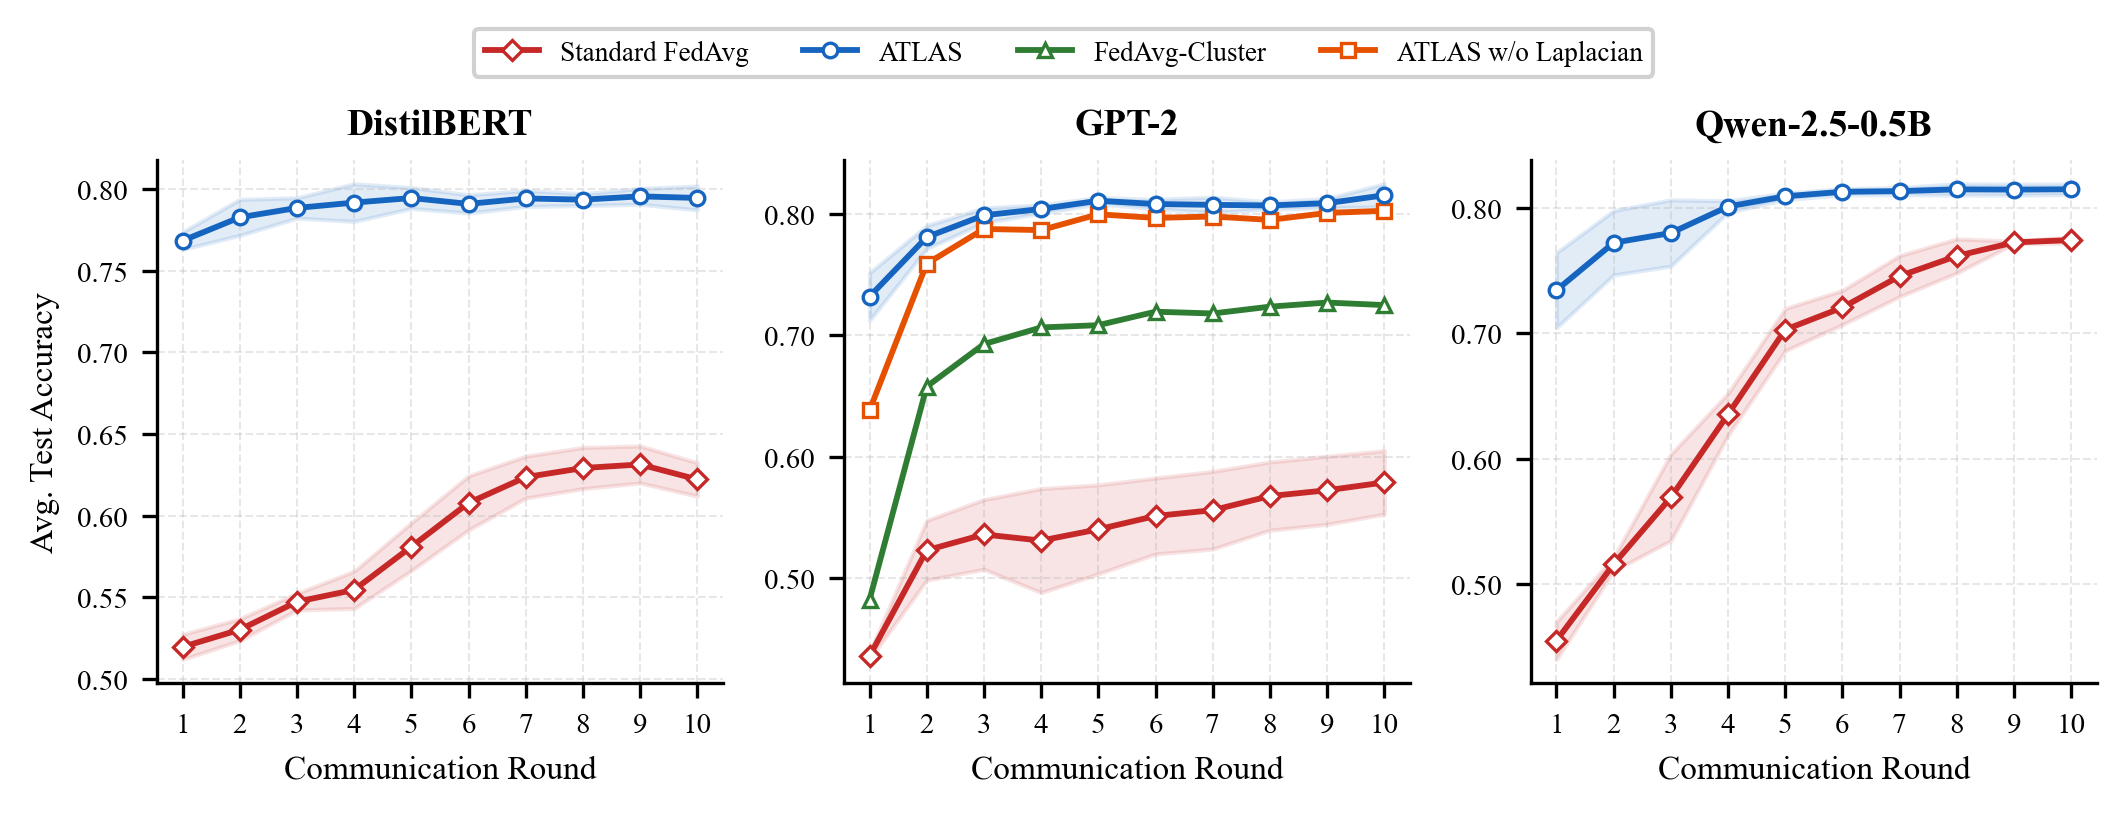

Saved fig3_convergence.pdf


In [39]:
# ── Fig. 3: Convergence — Accuracy over Rounds (IEEE 3-panel) ────────────────
def get_convergence(df_rows):
    """Return (rounds, mean_acc_list, std_acc_list) averaged over seeds."""
    all_curves = []
    for _, row in df_rows.iterrows():
        rm = row['round_metrics']
        if isinstance(rm, list) and rm:
            curve = [r['avg_accuracy'] for r in sorted(rm, key=lambda x: x['round'])]
            all_curves.append(curve)
    if not all_curves:
        return [], [], []
    min_len = min(len(c) for c in all_curves)
    arr = np.array([c[:min_len] for c in all_curves])
    return list(range(1, min_len + 1)), arr.mean(0).tolist(), arr.std(0).tolist()

models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]
n_models = len(models_present)

fig, axes = plt.subplots(1, n_models, figsize=(IEEE_2COL, 3.0), sharey=False)
if n_models == 1:
    axes = [axes]

legend_handles = {}

for ax, model in zip(axes, models_present):
    sub     = df[df['model'] == model]
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas'])
               if m in sub['method'].unique()]

    for method in methods:
        sub_m = sub[sub['method'] == method]
        rounds, means, stds = get_convergence(sub_m)
        if not rounds:
            continue
        c   = METHOD_COLORS[method]
        mkr = METHOD_MARKERS[method]
        line, = ax.plot(rounds, means, f'-{mkr}', color=c, label=METHOD_LABELS[method],
                        linewidth=1.4, markersize=3.5, markerfacecolor='white',
                        markeredgewidth=0.8)
        legend_handles.setdefault(METHOD_LABELS[method], line)
        if any(s > 1e-6 for s in stds):
            ax.fill_between(rounds,
                            [m - s for m, s in zip(means, stds)],
                            [m + s for m, s in zip(means, stds)],
                            color=c, alpha=0.12)

    ax.set_xlabel('Communication Round', fontsize=8)
    ax.set_ylabel('Avg. Test Accuracy' if ax == axes[0] else '', fontsize=8)
    ax.set_title(MODEL_LABELS[model], fontweight='bold', fontsize=9)
    ax.set_xticks(range(1, 11))
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

fig.legend(list(legend_handles.values()), list(legend_handles.keys()),
           fontsize=6.5, loc='upper center', bbox_to_anchor=(0.5, 0.90),
           ncol=min(len(legend_handles), 4), frameon=True)

plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.savefig(f'{RESULTS_DIR}/fig3_convergence.pdf', bbox_inches='tight')
plt.show()
print('Saved fig3_convergence.pdf')


---
## 7  Communication Cost vs Performance

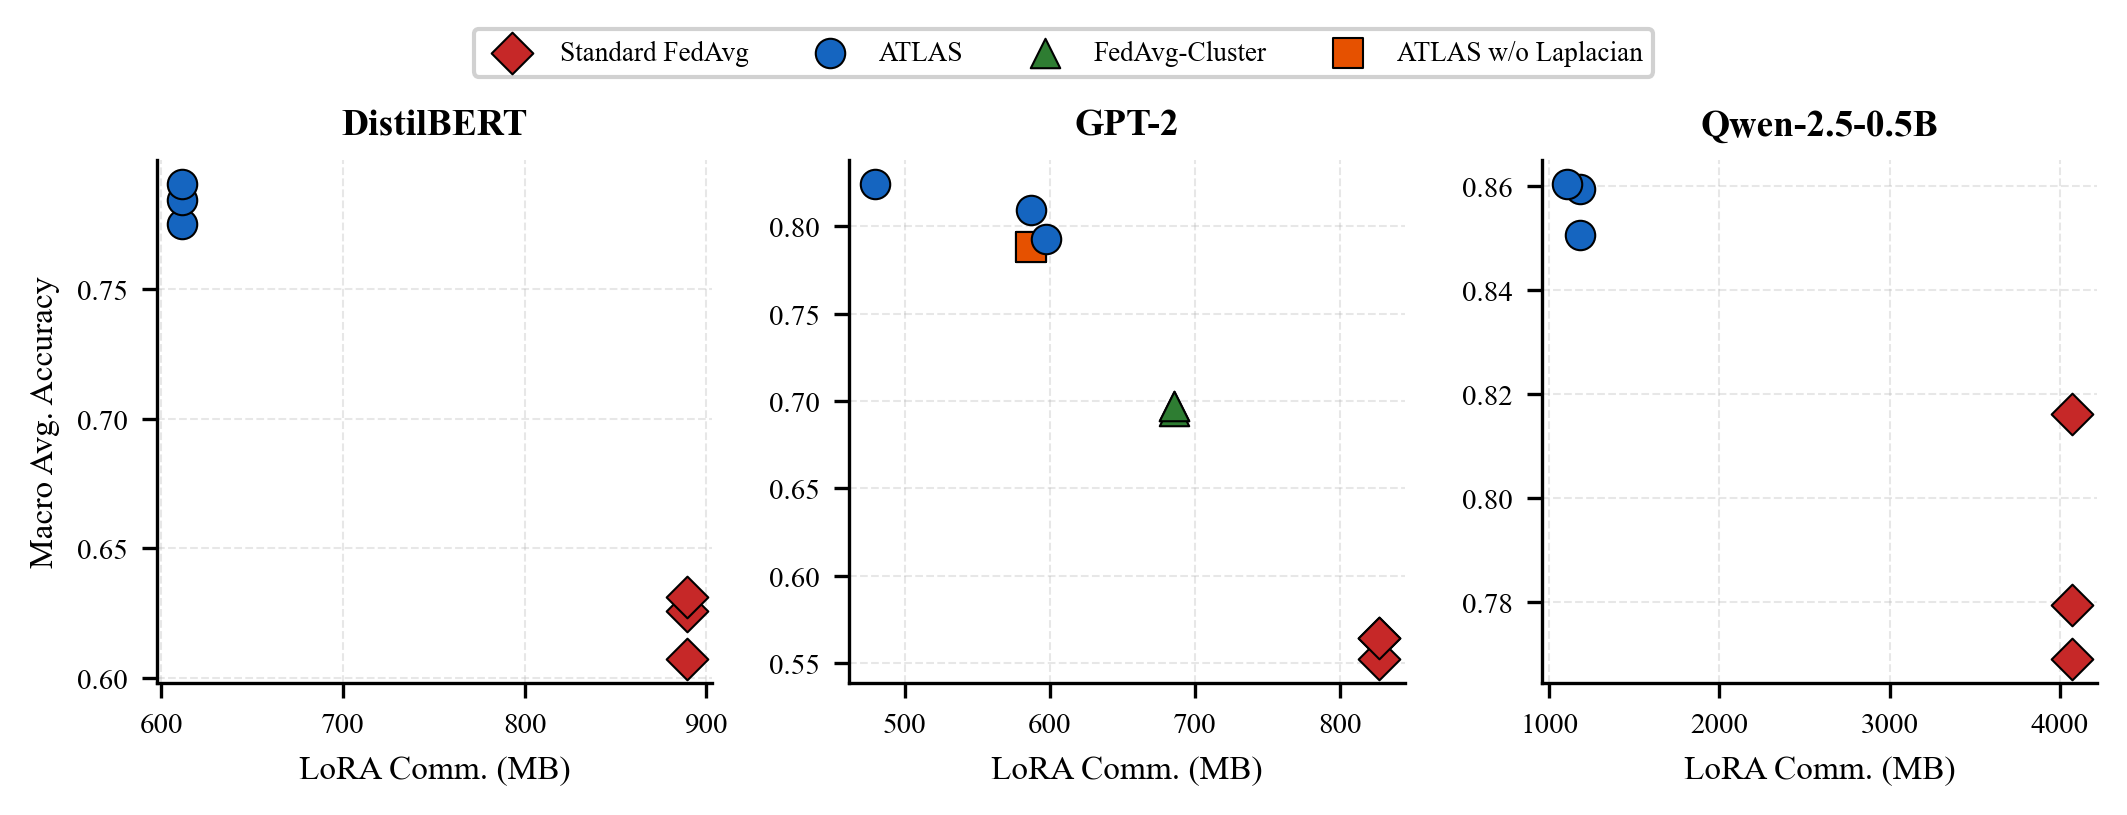

Saved fig5_lora_comm_vs_perf.pdf


In [48]:
# ── Fig. 5: LoRA Communication Cost vs Macro Accuracy (IEEE 3-panel) ─────────
models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]
n_models = len(models_present)

fig, axes = plt.subplots(1, n_models, figsize=(IEEE_2COL, 3.0), sharey=False)
if n_models == 1:
    axes = [axes]

legend_handles = {}

for ax, model in zip(axes, models_present):
    sub     = df[df['model'] == model]
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas'])
               if m in sub['method'].unique()]

    for method in methods:
        sub_m = sub[sub['method'] == method]
        mkr   = METHOD_MARKERS[method]
        scatter = ax.scatter(sub_m['lora_comm_mb'], sub_m['macro_acc'],
                             color=METHOD_COLORS[method], marker=mkr, s=50,
                             label=METHOD_LABELS[method],
                             edgecolors='black', linewidths=0.5, zorder=5)
        legend_handles.setdefault(METHOD_LABELS[method], scatter)

    ax.set_xlabel('LoRA Comm. (MB)', fontsize=8)
    ax.set_ylabel('Macro Avg. Accuracy' if ax == axes[0] else '', fontsize=8)
    ax.set_title(MODEL_LABELS[model], fontweight='bold', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))

fig.legend(list(legend_handles.values()), list(legend_handles.keys()),
           fontsize=6.5, loc='upper center', bbox_to_anchor=(0.5, 0.90),
           ncol=min(len(legend_handles), 4), frameon=True)
plt.tight_layout(rect=[0, 0, 1, 0.84])
plt.savefig(f'{RESULTS_DIR}/fig5_lora_comm_vs_perf.pdf', bbox_inches='tight')
plt.show()
print('Saved fig5_lora_comm_vs_perf.pdf')


---
## 8  Personalization Spread (Client Heterogeneity)

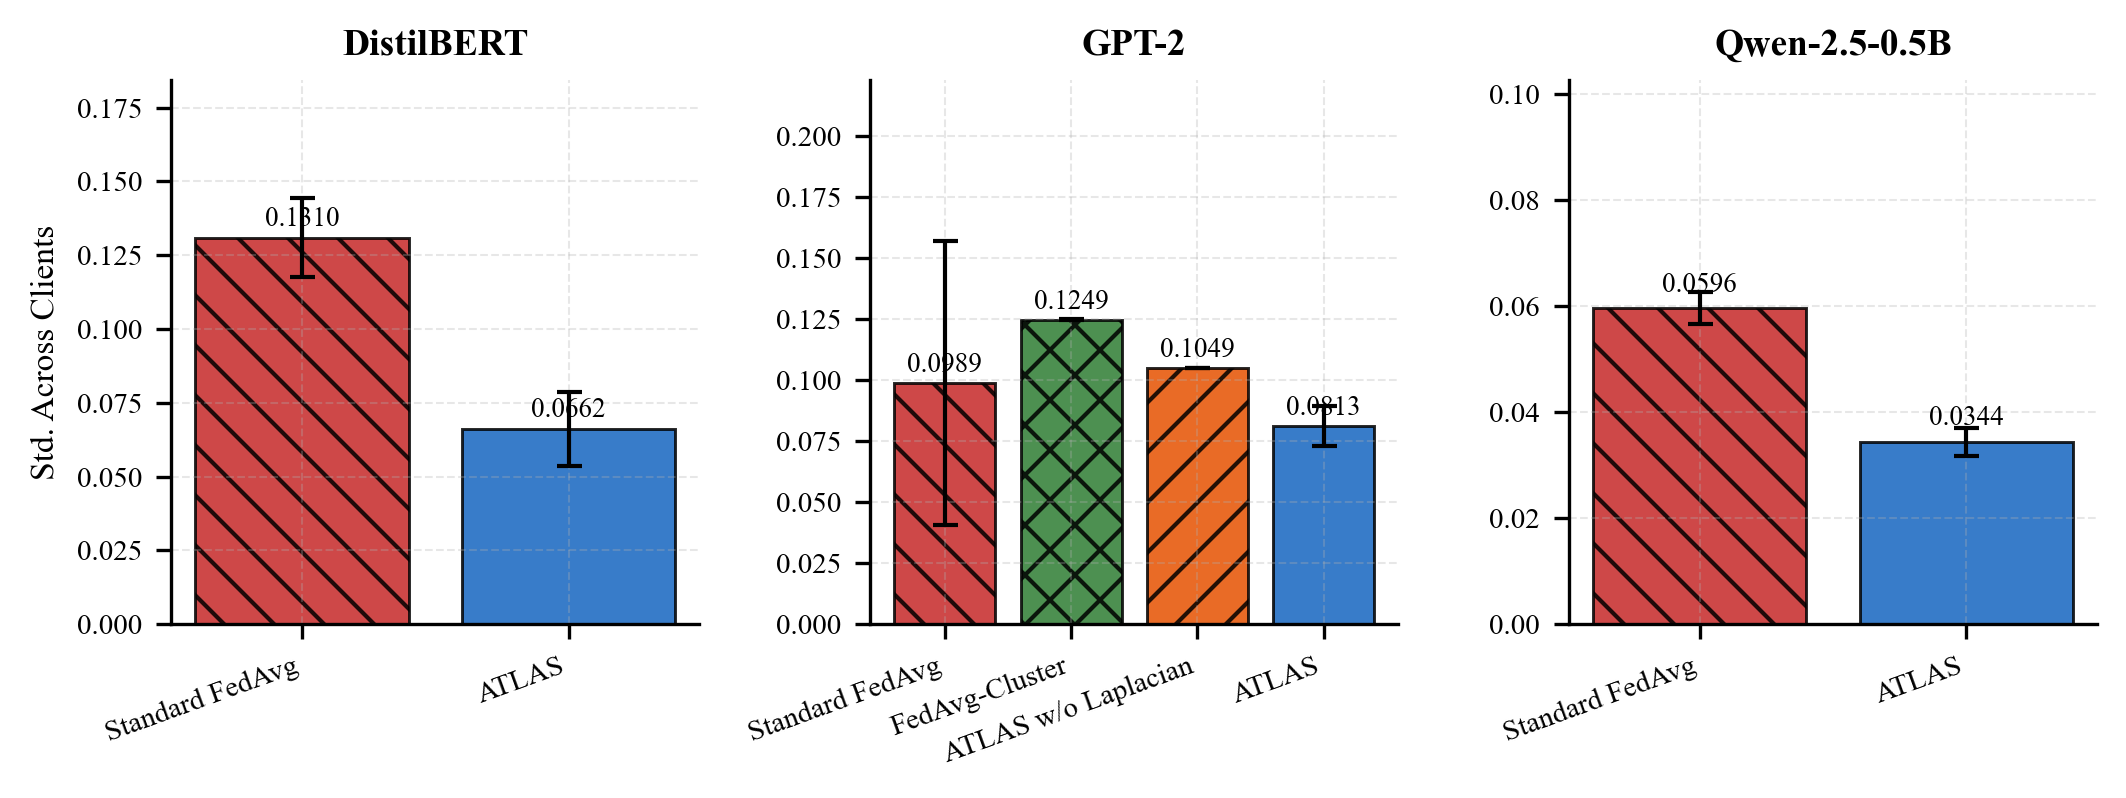

Saved fig6_personalization_spread.pdf


In [41]:
# ── Fig. 6: Personalization Spread (IEEE 3-panel) ────────────────────────────
models_present = [m for m in MODEL_ORDER if m in df['model'].unique()]
n_models = len(models_present)

fig, axes = plt.subplots(1, n_models, figsize=(IEEE_2COL, 3.0), sharey=False)
if n_models == 1:
    axes = [axes]

for ax, model in zip(axes, models_present):
    sub     = df[df['model'] == model]
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas'])
               if m in sub['method'].unique()]

    means  = [sub[sub['method'] == m]['personalization_spread'].mean() for m in methods]
    stds   = [sub[sub['method'] == m]['personalization_spread'].std(ddof=0) for m in methods]
    x      = np.arange(len(methods))
    colors = [METHOD_COLORS[m] for m in methods]
    hatch  = [METHOD_HATCHES[m] for m in methods]
    xlabs  = [METHOD_LABELS[m] for m in methods]

    bars = ax.bar(x, means, yerr=stds, capsize=3,
                  color=colors, hatch=hatch, alpha=0.85,
                  edgecolor='black', linewidth=0.7,
                  error_kw={'ecolor': 'black', 'elinewidth': 1.0})

    for bar, mv in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f'{mv:.4f}', ha='center', va='bottom', fontsize=6.5)

    ax.set_xticks(x)
    ax.set_xticklabels(xlabs, fontsize=7, rotation=20, ha='right')
    ax.set_ylabel('Std. Across Clients' if ax == axes[0] else '', fontsize=8)
    ax.set_title(MODEL_LABELS[model], fontweight='bold', fontsize=9)
    ax.set_ylim(0, max(means) + max(stds) + 0.04)
    ax.tick_params(axis='y', labelsize=7)

plt.tight_layout(rect=[0, 0, 1, 0.91])
plt.savefig(f'{RESULTS_DIR}/fig6_personalization_spread.pdf', bbox_inches='tight')
plt.show()
print('Saved fig6_personalization_spread.pdf')


---
## 10  Clustering Visualization — Fingerprint Space & Cluster Means


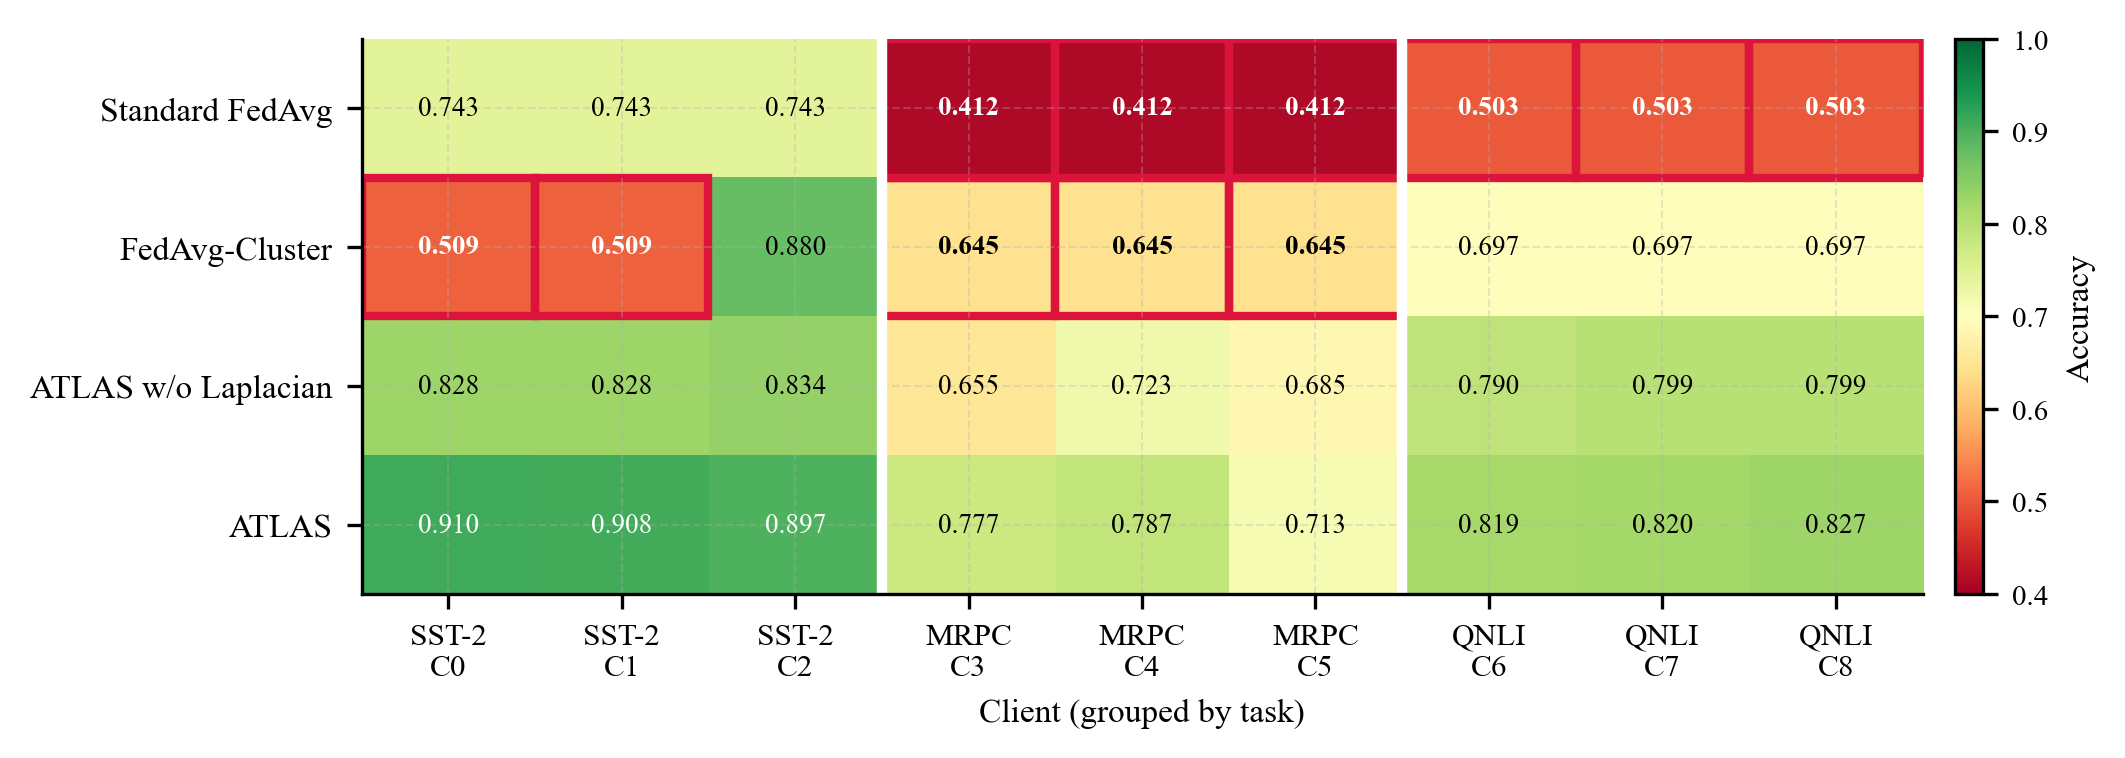

Client failure summary (GPT-2, seed 42):
  Standard FedAvg               : 6 failing clients  [3, 4, 5, 6, 7, 8]
  FedAvg-Cluster                : 5 failing clients  [0, 1, 3, 4, 5]
  ATLAS w/o Laplacian           : 0 failing clients  []
  ATLAS                         : 0 failing clients  []


In [42]:
# ── Fig. 7: Per-Client Accuracy Heatmap (GPT-2, all methods, seed 42) ────────
# GPT-2 seed-42 comparison across all methods
gpt2_s42   = df[(df['model'] == 'GPT-2') & (df['seed'] == 42)].copy()
method_order_gpt2 = ['standard_fl', 'fedavg_cluster', 'atlas_no_laplacian', 'atlas']
methods    = [m for m in method_order_gpt2 if m in gpt2_s42['method'].unique()]

data_mat   = np.full((len(methods), 9), np.nan)
for i, method in enumerate(methods):
    row_data = gpt2_s42[gpt2_s42['method'] == method]
    if row_data.empty:
        continue
    fa = row_data.iloc[0]['final_accuracies']
    data_mat[i] = [fa.get(str(c), np.nan) for c in range(9)]

task_labels = [f'{TASK_MAP[c]}\nC{c}' for c in range(9)]
y_labels    = [METHOD_LABELS[m] for m in methods]

fig, ax = plt.subplots(figsize=(IEEE_2COL, 2.6))
im = ax.imshow(data_mat, cmap='RdYlGn', vmin=0.4, vmax=1.0, aspect='auto')
cbar = plt.colorbar(im, ax=ax, label='Accuracy', pad=0.02, fraction=0.03)
cbar.ax.tick_params(labelsize=7)
cbar.set_label('Accuracy', fontsize=8)

ax.set_xticks(range(9))
ax.set_xticklabels(task_labels, fontsize=7.5)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels(y_labels, fontsize=8)

# Annotate cells + mark failures
for i in range(len(methods)):
    for j in range(9):
        v = data_mat[i, j]
        if np.isnan(v):
            continue
        is_fail  = v < FAIL_THRESH
        txt_col  = 'white' if v < 0.55 or v > 0.88 else 'black'
        annot    = f'{v:.3f}'
        ax.text(j, i, annot, ha='center', va='center',
                fontsize=6.5, color=txt_col,
                fontweight='bold' if is_fail else 'normal')
        if is_fail:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                        fill=False, edgecolor='crimson',
                                        linewidth=2.0))

# Task group separator lines
for xv in [2.5, 5.5]:
    ax.axvline(xv, color='white', linewidth=2.5)

# Failure threshold annotation on y-axis
ax.set_xlabel('Client (grouped by task)', fontsize=8)


plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/fig7_client_heatmap.pdf', bbox_inches='tight')
plt.show()

# Summary of failures
print('Client failure summary (GPT-2, seed 42):')
for i, method in enumerate(methods):
    fails = [j for j in range(9) if not np.isnan(data_mat[i, j]) and data_mat[i, j] < FAIL_THRESH]
    print(f'  {METHOD_LABELS[method]:30s}: {len(fails)} failing clients  {fails}')


---
## 11  Ablation: Laplacian Contribution (GPT-2)


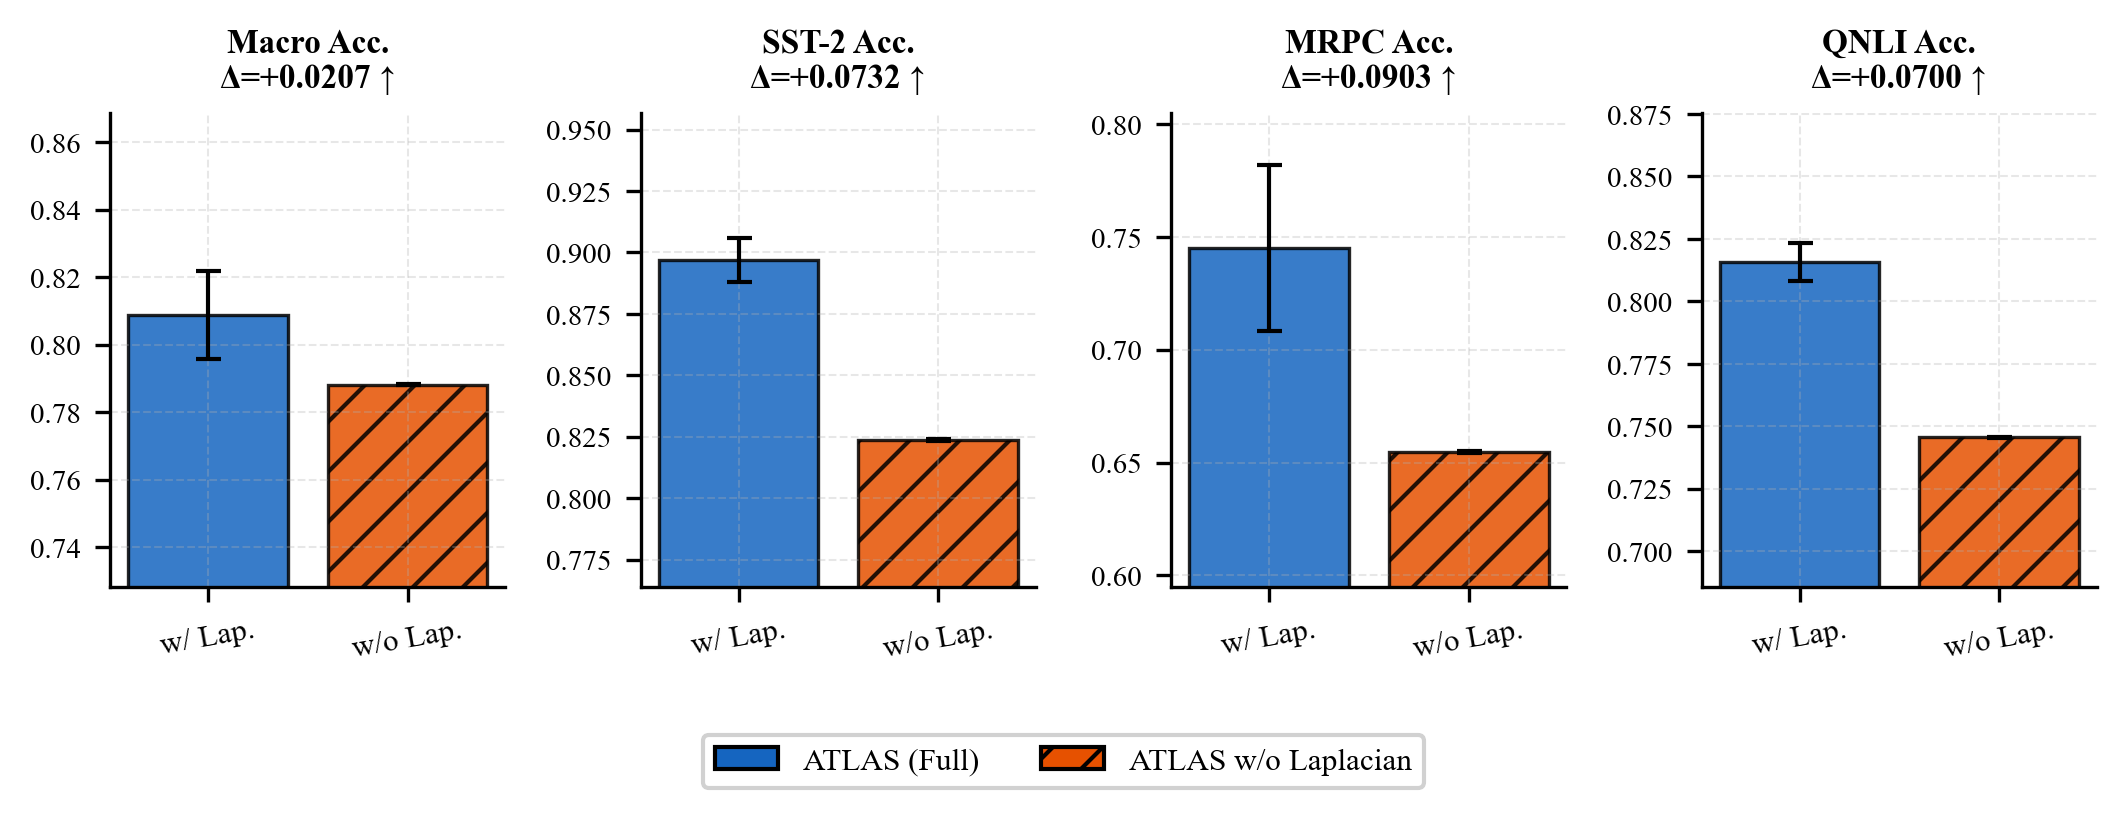

Saved fig8_ablation_laplacian.pdf

Laplacian adds: Δmacro_acc=+0.0207,  Δpers_spread=-0.0236


In [43]:
# ── Fig. 8: Ablation — Laplacian Contribution (GPT-2 only) ───────────────────
# NOTE: Ablation study (no-Laplacian / FedAvg-Cluster) is only run for GPT-2.
gpt2_df   = df[df['model'] == 'GPT-2']
atlas_full = gpt2_df[gpt2_df['method'] == 'atlas']
atlas_noL  = gpt2_df[gpt2_df['method'] == 'atlas_no_laplacian']

if atlas_noL.empty:
    print('[SKIP] No atlas_no_laplacian results for GPT-2 — run ablation experiment first.')
else:
    metrics = [('macro_acc', 'Macro Acc.'),
               ('acc_sst2', 'SST-2 Acc.'),
               ('acc_mrpc', 'MRPC Acc.'),
               ('acc_qnli', 'QNLI Acc.'),]

    fig, axes = plt.subplots(1, len(metrics), figsize=(IEEE_2COL, 2.8))

    for ax, (col, label) in zip(axes, metrics):
        full_v = atlas_full[col].dropna().values
        noL_v  = atlas_noL[col].dropna().values

        ax.bar([0, 1], [full_v.mean(), noL_v.mean()],
               yerr=[full_v.std(ddof=0) if len(full_v) > 1 else 0,
                     noL_v.std(ddof=0)  if len(noL_v)  > 1 else 0],
               capsize=3,
               color=[METHOD_COLORS['atlas'], METHOD_COLORS['atlas_no_laplacian']],
               hatch=['', '//'], alpha=0.85, edgecolor='black', linewidth=0.8,
               error_kw={'ecolor': 'black', 'elinewidth': 1.0})

        delta = full_v.mean() - noL_v.mean()
        better = ((delta > 0 and col != 'personalization_spread') or
                  (delta < 0 and col == 'personalization_spread'))
        arrow = '↑' if better else '↓'
        sign  = '+' if delta >= 0 else ''
        ax.set_title(f'{label}\nΔ={sign}{delta:.4f} {arrow}',
                     fontsize=8, fontweight='bold')
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['w/ Lap.', 'w/o Lap.'], fontsize=7.5, rotation=10)
        ax.tick_params(axis='y', labelsize=7)
        ylo = max(0, min(full_v.mean(), noL_v.mean()) - 0.06)
        yhi = max(full_v.mean(), noL_v.mean()) + 0.06
        ax.set_ylim(ylo, yhi)

    # Legend patches
    legend_handles = [
        Patch(facecolor=METHOD_COLORS['atlas'],              hatch='',   edgecolor='black', label='ATLAS (Full)'),
        Patch(facecolor=METHOD_COLORS['atlas_no_laplacian'], hatch='//', edgecolor='black', label='ATLAS w/o Laplacian'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=7.5, bbox_to_anchor=(0.5, -0.04), frameon=True)

    plt.tight_layout(rect=[0, 0.08, 1, 0.93])
    plt.savefig(f'{RESULTS_DIR}/fig8_ablation_laplacian.pdf', bbox_inches='tight')
    plt.show()
    print('Saved fig8_ablation_laplacian.pdf')

    # Numeric summary
    d = atlas_full['macro_acc'].mean() - atlas_noL['macro_acc'].mean()
    dp = atlas_full['personalization_spread'].mean() - atlas_noL['personalization_spread'].mean()
    print(f'\nLaplacian adds: Δmacro_acc={d:+.4f},  Δpers_spread={dp:+.4f}')


---
## 11  GPT-2 Weak-Device Analysis

> This section uses the JSON field `weak_device_dropped` directly, so the reported weak devices match the experiment outputs rather than an accuracy-threshold heuristic.

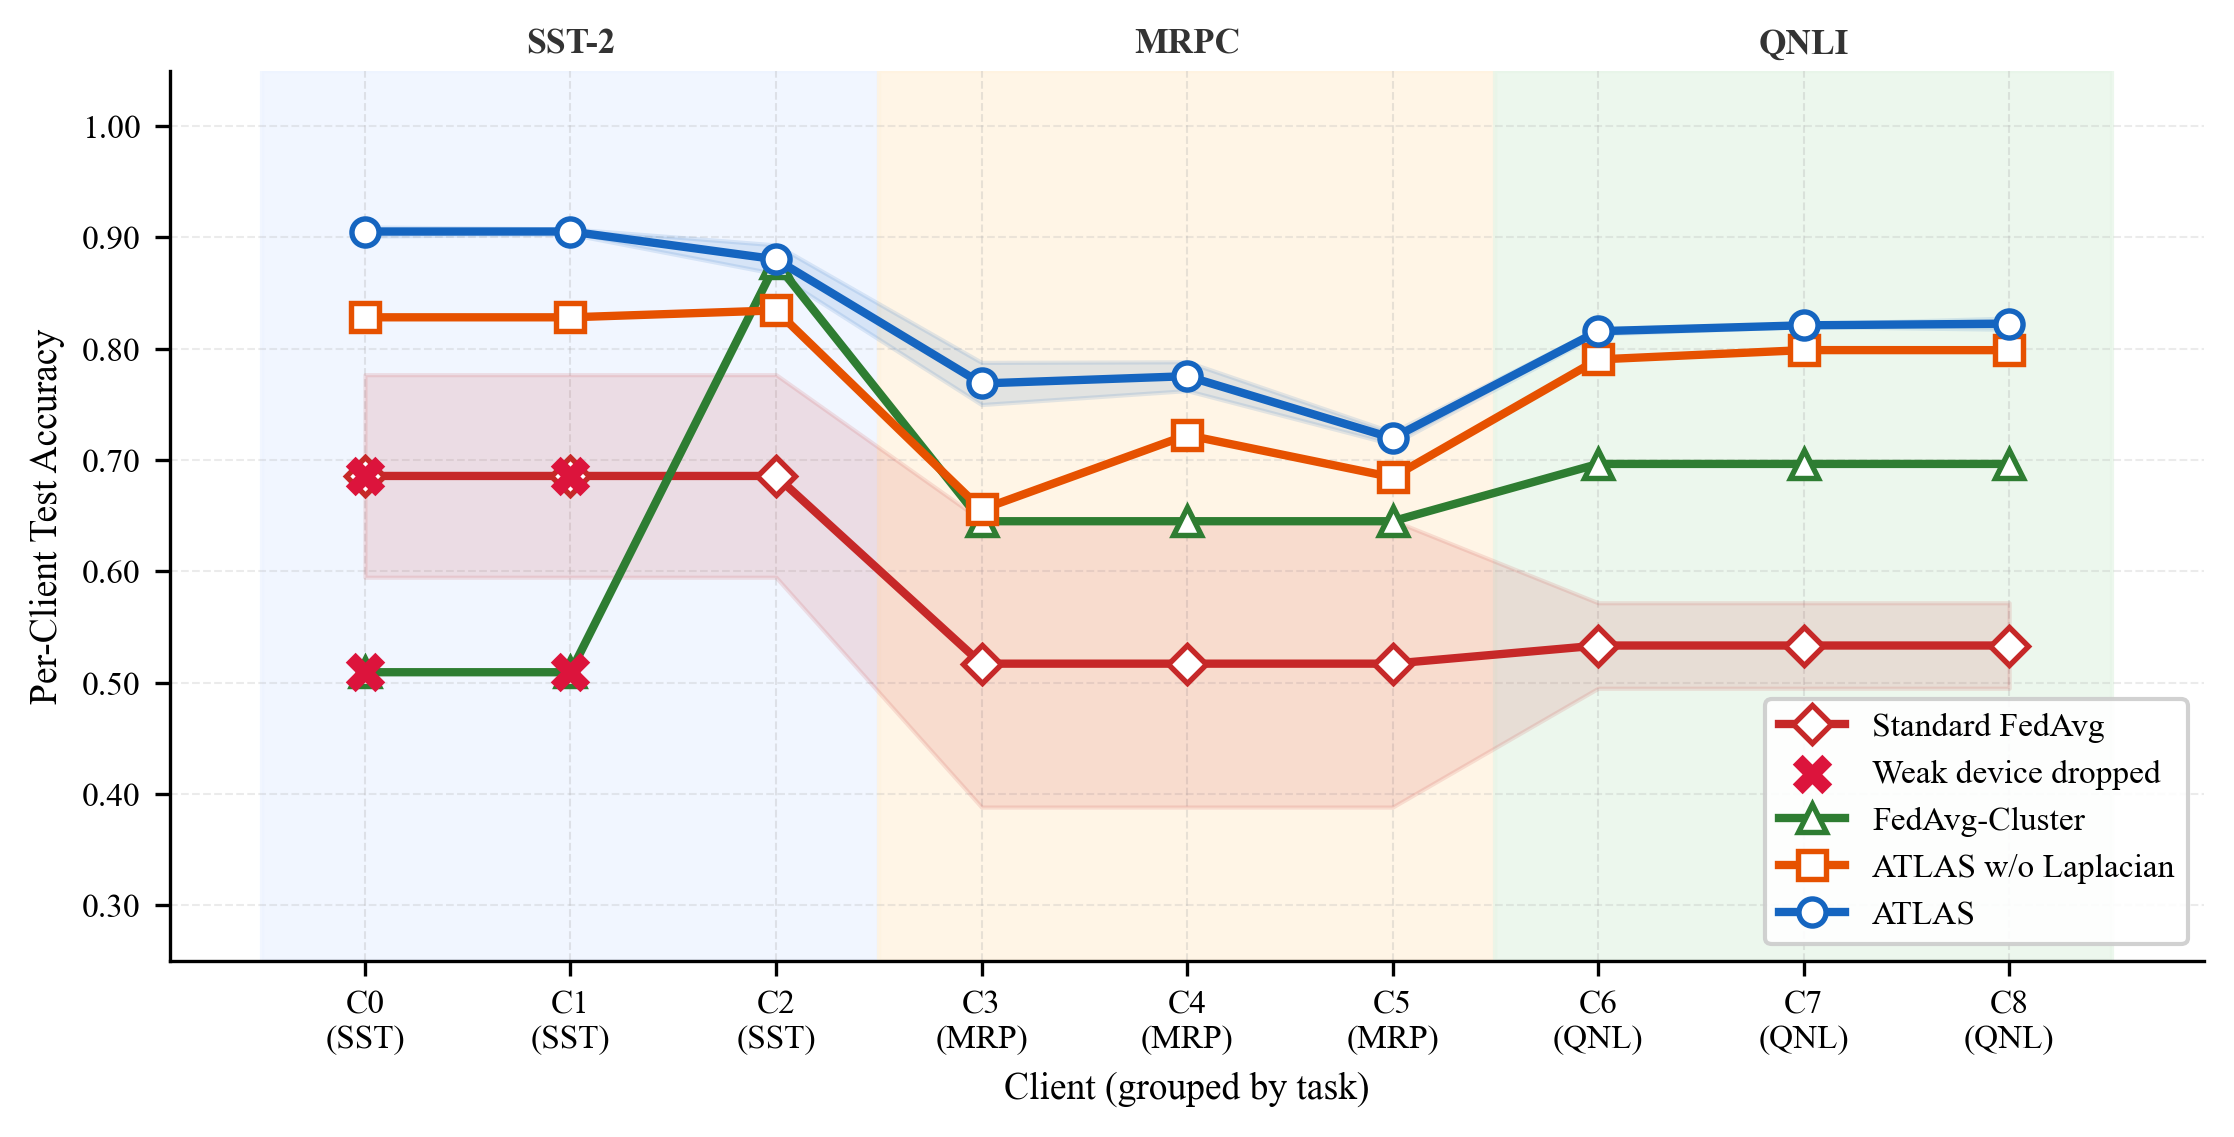

Saved fig9_client_failures.pdf

JSON weak-device summary for GPT-2:
Method                          Mean dropped weak devices         Reported clients
--------------------------------------------------------------------------------------
Standard FedAvg                                       2.0                   C0, C1
FedAvg-Cluster                                        2.0                   C0, C1
ATLAS w/o Laplacian                                   0.0                        -
ATLAS                                                 0.0                        -


In [44]:
# ── Fig. 9: GPT-2 weak-device analysis from JSON metadata ─────────────────────
gpt2_df = df[df['model'] == 'GPT-2'].copy()

if gpt2_df.empty:
    print('[SKIP] No GPT-2 runs found in the results directory.')
else:
    fig, ax = plt.subplots(figsize=(IEEE_2COL * 1.05, 4.2))

    client_ids = list(range(9))
    task_labels = [f'C{c}\n({TASK_MAP[c][:3]})' for c in client_ids]
    task_groups = [(0, 2, 'SST-2'), (3, 5, 'MRPC'), (6, 8, 'QNLI')]
    task_bg = ['#EEF4FF', '#FFF3E0', '#E8F5E9']
    legend_items = {}

    for (lo, hi, tname), bg in zip(task_groups, task_bg):
        ax.axvspan(lo - 0.5, hi + 0.5, color=bg, alpha=0.8, zorder=0)
        ax.text((lo + hi) / 2, 1.01, tname, ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#333333',
                transform=ax.get_xaxis_transform())

    compare_methods = ['standard_fl', 'fedavg_cluster', 'atlas_no_laplacian', 'atlas']
    compare_methods = [m for m in compare_methods if m in gpt2_df['method'].unique()]

    for method in compare_methods:
        sub_m = gpt2_df[gpt2_df['method'] == method]
        if sub_m.empty:
            continue

        per_client_rows = []
        weak_sets = []
        for _, row in sub_m.iterrows():
            vals = row['per_client_acc']
            if isinstance(vals, (list, tuple, np.ndarray)) and len(vals) == len(client_ids):
                per_client_rows.append(vals)

            weak = row['weak_device_dropped']
            if not isinstance(weak, dict):
                weak = {}
            weak_sets.append({int(cid) for cid in weak.keys() if str(cid).isdigit()})

        if not per_client_rows:
            continue

        per_client_over_seeds = np.array(per_client_rows, dtype=float)
        mean_acc = per_client_over_seeds.mean(axis=0)
        std_acc = per_client_over_seeds.std(axis=0)

        color = METHOD_COLORS[method]
        marker = METHOD_MARKERS[method]
        x = np.array(client_ids, dtype=float)

        line, = ax.plot(
            x,
            mean_acc,
            f'-{marker}',
            color=color,
            label=METHOD_LABELS[method],
            linewidth=2.0,
            markersize=6.5,
            markerfacecolor='white',
            markeredgewidth=1.3,
            zorder=5,
        )
        ax.fill_between(x, mean_acc - std_acc, mean_acc + std_acc,
                        color=color, alpha=0.12, zorder=4)
        legend_items.setdefault(METHOD_LABELS[method], line)

        reported_weak_clients = sorted({cid for weak_set in weak_sets for cid in weak_set})
        for cid in reported_weak_clients:
            weak_marker = ax.scatter(cid, mean_acc[cid], marker='X', color='crimson',
                                     s=90, zorder=8, linewidths=0)
            legend_items.setdefault('Weak device dropped', weak_marker)

    ax.set_ylim(0.25, 1.05)
    ax.set_xticks(client_ids)
    ax.set_xticklabels(task_labels, fontsize=8)
    ax.set_xlabel('Client (grouped by task)', fontsize=9)
    ax.set_ylabel('Per-Client Test Accuracy', fontsize=9)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.2f}'))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='y', alpha=0.25, linestyle='--')

    legend_handles = list(legend_items.values())
    legend_labels = list(legend_items.keys())
    ax.legend(legend_handles, legend_labels, fontsize=8, loc='lower right', frameon=True)

    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.savefig(f'{RESULTS_DIR}/fig9_client_failures.pdf', bbox_inches='tight')
    plt.show()
    print('Saved fig9_client_failures.pdf')

    print('\nJSON weak-device summary for GPT-2:')
    print(f'{"Method":<30} {"Mean dropped weak devices":>26} {"Reported clients":>24}')
    print('-' * 86)
    for method in compare_methods:
        sub_m = gpt2_df[gpt2_df['method'] == method]
        weak_counts = []
        reported_union = set()
        for _, row in sub_m.iterrows():
            weak = row['weak_device_dropped']
            if not isinstance(weak, dict):
                weak = {}
            weak_clients = {int(cid) for cid in weak.keys() if str(cid).isdigit()}
            weak_counts.append(len(weak_clients))
            reported_union.update(weak_clients)
        reported_text = ', '.join(f'C{cid}' for cid in sorted(reported_union)) if reported_union else '-'
        mean_weak = np.mean(weak_counts) if weak_counts else 0.0
        print(f'{METHOD_LABELS[method]:<30} {mean_weak:>26.1f} {reported_text:>24}')

---
## 13  Summary: Key Takeaways


In [45]:
print('=' * 72)
print('  ATLAS RESULTS — KEY TAKEAWAYS')
print('=' * 72)

for model in MODEL_ORDER:
    sub = summary[summary['model'] == model]
    if sub.empty:
        continue
    print(f'\n--- {MODEL_LABELS[model]} ---')

    atlas_m  = sub[sub['method'] == 'atlas']
    std_fl_m = sub[sub['method'] == 'standard_fl']

    if not atlas_m.empty:
        n_s = atlas_m['n_seeds'].values[0]
        print(f'  ATLAS Macro Acc   : {atlas_m["macro_acc_mean"].values[0]:.4f}'
              f' ± {atlas_m["macro_acc_std"].values[0]:.4f}  [{n_s} seeds]')
    if not std_fl_m.empty:
        n_s = std_fl_m['n_seeds'].values[0]
        print(f'  Std FL Macro Acc  : {std_fl_m["macro_acc_mean"].values[0]:.4f}'
              f' ± {std_fl_m["macro_acc_std"].values[0]:.4f}  [{n_s} seeds]')
        if not atlas_m.empty:
            gain = atlas_m['macro_acc_mean'].values[0] - std_fl_m['macro_acc_mean'].values[0]
            fail_atlas = atlas_m['n_failing_clients_mean'].values[0]
            fail_std   = std_fl_m['n_failing_clients_mean'].values[0]
            print(f'  → ATLAS gain      : +{gain:.4f} ({gain*100:.2f}%)')
            print(f'  → Failing clients : StdFL={fail_std:.1f}/9,  ATLAS={fail_atlas:.1f}/9  '
                  f'(ATLAS saves {fail_std - fail_atlas:.1f} clients)')

    if model == 'GPT-2':
        fed_clust = sub[sub['method'] == 'fedavg_cluster']
        noL_m     = sub[sub['method'] == 'atlas_no_laplacian']
        if not fed_clust.empty:
            print(f'  FedAvg-Cluster    : {fed_clust["macro_acc_mean"].values[0]:.4f}'
                  f'  (fail: {fed_clust["n_failing_clients_mean"].values[0]:.1f}/9)')
        if not noL_m.empty and not atlas_m.empty:
            lap_gain = atlas_m['macro_acc_mean'].values[0] - noL_m['macro_acc_mean'].values[0]
            print(f'  ATLAS w/o Laplace : {noL_m["macro_acc_mean"].values[0]:.4f}')
            print(f'  → Laplacian adds  : {lap_gain:+.4f}')

    # LoRA communication
    if not atlas_m.empty and not std_fl_m.empty:
        la = atlas_m['lora_comm_mb_mean'].values[0]
        ls = std_fl_m['lora_comm_mb_mean'].values[0]
        ratio_str = f'   ratio: {la/ls:.2f}x' if ls > 0 else ''
        print(f'  LoRA comm (ATLAS) : {la:,.1f} MB   StdFL: {ls:,.1f} MB{ratio_str}')

print('\n' + '=' * 72)
print('  FIGURES SAVED (IEEE 300dpi):')
for figname in ['fig1_macro_accuracy', 'fig2_per_task_accuracy',
                'fig3_convergence', 'fig5_lora_comm_vs_perf',
                'fig6_personalization_spread', 'fig7_client_heatmap',
                'fig8_ablation_laplacian', 'fig9_client_failures',
                'fig10_clustering']:
    path = f'{RESULTS_DIR}/{figname}.pdf'
    exists = '✓' if os.path.exists(path) else '✗'
    print(f'  {exists}  {figname}.pdf')
print('=' * 72)


  ATLAS RESULTS — KEY TAKEAWAYS

--- DistilBERT ---
  ATLAS Macro Acc   : 0.7832 ± 0.0078  [3 seeds]
  Std FL Macro Acc  : 0.6214 ± 0.0125  [3 seeds]
  → ATLAS gain      : +0.1618 (16.18%)
  → Failing clients : StdFL=2.0/9,  ATLAS=0.0/9  (ATLAS saves 2.0 clients)
  LoRA comm (ATLAS) : 611.4 MB   StdFL: 889.3 MB   ratio: 0.69x

--- GPT-2 ---
  ATLAS Macro Acc   : 0.8088 ± 0.0158  [3 seeds]
  Std FL Macro Acc  : 0.5605 ± 0.0071  [3 seeds]
  → ATLAS gain      : +0.2483 (24.83%)
  → Failing clients : StdFL=2.0/9,  ATLAS=0.0/9  (ATLAS saves 2.0 clients)
  FedAvg-Cluster    : 0.6962  (fail: 2.0/9)
  ATLAS w/o Laplace : 0.7881
  → Laplacian adds  : +0.0207
  LoRA comm (ATLAS) : 554.7 MB   StdFL: 827.4 MB   ratio: 0.67x

--- Qwen-2.5-0.5B ---
  ATLAS Macro Acc   : 0.8568 ± 0.0054  [3 seeds]
  Std FL Macro Acc  : 0.7882 ± 0.0247  [3 seeds]
  → ATLAS gain      : +0.0686 (6.86%)
  → Failing clients : StdFL=2.0/9,  ATLAS=0.0/9  (ATLAS saves 2.0 clients)
  LoRA comm (ATLAS) : 1,154.0 MB   StdFL: 4,

---
## 14  LaTeX Table Export for Paper

The cells below generate paper-ready LaTeX tables directly from the analyzed JSON results.

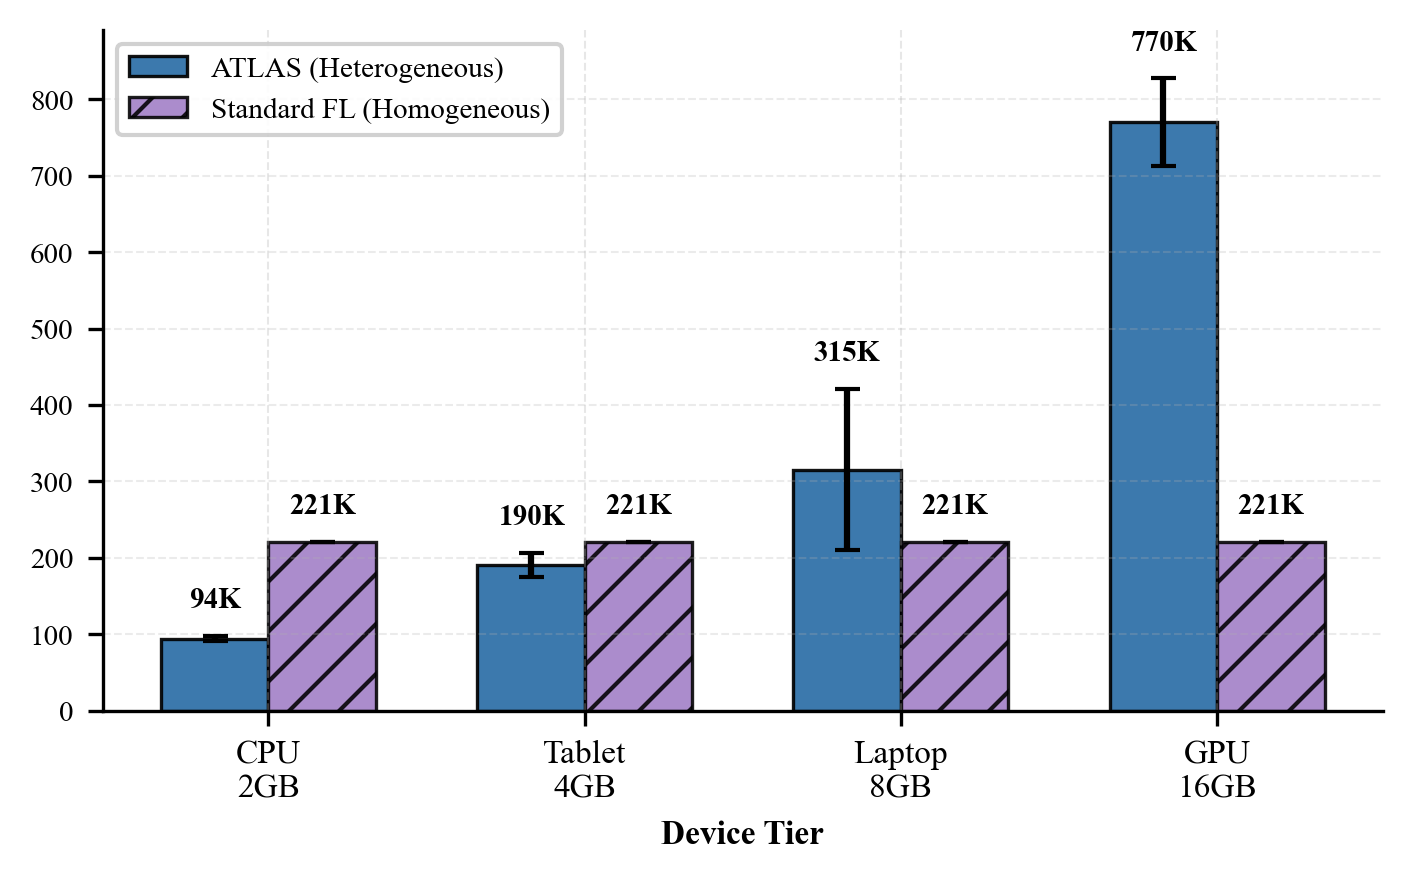

Saved fig10_device_allocation.pdf


,Method,Device,Approx Params (K),Std
0,atlas,CPU\n2GB,94.208,3.172748
1,standard_fl,CPU\n2GB,221.184,0.000000
2,atlas,Tablet\n4GB,190.464,16.255496
3,standard_fl,Tablet\n4GB,221.184,0.000000
4,atlas,Laptop\n8GB,315.392,105.895662
5,standard_fl,Laptop\n8GB,221.184,0.000000
6,atlas,GPU\n16GB,770.048,57.460909
7,standard_fl,GPU\n16GB,221.184,0.000000


In [46]:
# ── Fig. 10: Device-aware parameter allocation (GPT-2, mean over seeds) ──────
# Map device-string keys (as stored in JSON) to memory in MB
_DEVICE_MEMORY_MB = {
    'cpu_2gb':    2048,
    'tablet_4gb': 4096,
    'laptop_8gb': 8192,
    'gpu_16gb':   16384,
}

def device_label_from_memory(memory_mb):
    if memory_mb <= 2048:
        return 'CPU\n2GB'
    if memory_mb <= 4096:
        return 'Tablet\n4GB'
    if memory_mb <= 8192:
        return 'Laptop\n8GB'
    return 'GPU\n16GB'

def iter_phase2_entries(raw):
    if isinstance(raw, dict):
        items = raw.values()
    elif isinstance(raw, list):
        items = raw
    else:
        items = []
    for item in items:
        if not isinstance(item, dict):
            continue
        ranks = item.get('lora_ranks', item.get('ranks', []))
        if not isinstance(ranks, list) or not ranks:
            continue
        # Support both old schema (device_profile.memory_mb) and new schema (device string)
        device_str = item.get('device', '')
        memory_mb = _DEVICE_MEMORY_MB.get(device_str)
        if memory_mb is None:
            profile = item.get('device_profile', {})
            memory_mb = profile.get('memory_mb')
        if memory_mb is None:
            continue
        yield {
            'device_label': device_label_from_memory(memory_mb),
            'rank_sum': float(np.sum(ranks)),
        }

device_records = []
for _, row in df[df['model'] == 'GPT-2'].iterrows():
    for entry in iter_phase2_entries(row['phase2_rank_allocation']):
        device_records.append({
            'method': row['method'],
            'seed': row['seed'],
            **entry,
        })

device_df = pd.DataFrame(device_records)
device_df = device_df[device_df['method'].isin(['atlas', 'standard_fl'])].copy()
device_df['approx_params_k'] = 2.0 * 768.0 * device_df['rank_sum'] / 1000.0

device_order = ['CPU\n2GB', 'Tablet\n4GB', 'Laptop\n8GB', 'GPU\n16GB']
plot_df = (
    device_df.groupby(['method', 'device_label'])['approx_params_k']
    .agg(['mean', 'std'])
    .reset_index()
 )
plot_df['device_sort'] = plot_df['device_label'].map({d: i for i, d in enumerate(device_order)})
plot_df = plot_df.sort_values(['device_sort', 'method']).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(IEEE_1COL * 1.35, 3.2))
x = np.arange(len(device_order))
w = 0.34

atlas_vals = [plot_df[(plot_df['device_label'] == d) & (plot_df['method'] == 'atlas')]['mean'].iloc[0] for d in device_order]
atlas_std  = [plot_df[(plot_df['device_label'] == d) & (plot_df['method'] == 'atlas')]['std'].iloc[0] for d in device_order]
std_vals   = [plot_df[(plot_df['device_label'] == d) & (plot_df['method'] == 'standard_fl')]['mean'].iloc[0] for d in device_order]
std_std    = [plot_df[(plot_df['device_label'] == d) & (plot_df['method'] == 'standard_fl')]['std'].iloc[0] for d in device_order]

bars1 = ax.bar(x - w / 2, atlas_vals, w, yerr=atlas_std, capsize=3,
               color='#2B6EA6', edgecolor='black', linewidth=0.8,
               alpha=0.92, label='ATLAS (Heterogeneous)')
bars2 = ax.bar(x + w / 2, std_vals, w, yerr=std_std, capsize=3,
               color='#A07CC5', edgecolor='black', linewidth=0.8,
               alpha=0.88, hatch='//', label='Standard FL (Homogeneous)')

ymax = max(
    max(v + (0 if np.isnan(s) else s) for v, s in zip(atlas_vals, atlas_std)),
    max(v + (0 if np.isnan(s) else s) for v, s in zip(std_vals, std_std)),
)
label_pad = max(12.0, 0.035 * ymax)

for bars, vals, errs in [(bars1, atlas_vals, atlas_std), (bars2, std_vals, std_std)]:
    for bar, val, err in zip(bars, vals, errs):
        err = 0.0 if np.isnan(err) else err
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + err + label_pad,
            f'{val:.0f}K',
            ha='center',
            va='bottom',
            fontsize=7,
            fontweight='bold',
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.92, boxstyle='round,pad=0.18'),
            clip_on=False,
        )

ax.set_ylim(0, ymax + 2.2 * label_pad)
ax.set_xticks(x)
ax.set_xticklabels(device_order, fontsize=8)
ax.set_xlabel('Device Tier', fontsize=8, fontweight='bold')
ax.legend(fontsize=7, loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.tick_params(axis='y', labelsize=7)
ax.grid(axis='y', alpha=0.25, linestyle='--')


plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(f'{RESULTS_DIR}/fig10_device_allocation.pdf', bbox_inches='tight')
plt.show()
print('Saved fig10_device_allocation.pdf')

display(
    plot_df[['method', 'device_label', 'mean', 'std']]
    .rename(columns={'method': 'Method', 'device_label': 'Device', 'mean': 'Approx Params (K)', 'std': 'Std'})
 )


---
## 14  Device-Aware Parameter Allocation

This section summarizes how ATLAS allocates LoRA capacity across device tiers compared with the homogeneous baseline. The plot and table use the GPT-2 runs and average across the three seeds for each method.

In [ ]:
# ── Export LaTeX tables for the paper ─────────────────────────
from pathlib import Path

TABLES_DIR = Path(RESULTS_DIR)
MAIN_TABLE_PATH = TABLES_DIR / 'paper_table_main_results.tex'
ABLATION_TABLE_PATH = TABLES_DIR / 'paper_table_gpt2_ablation.tex'
EFFICIENCY_TABLE_PATH = TABLES_DIR / 'paper_table_efficiency_summary.tex'
DEVICE_ALLOC_TABLE_PATH = TABLES_DIR / 'paper_table_device_allocation.tex'

def fmt_pm(mean_val, std_val, digits=4):
    if pd.isna(std_val):
        return f"{mean_val:.{digits}f}"
    return f"{mean_val:.{digits}f} $\\pm$ {std_val:.{digits}f}"

def fmt_num(val, digits=1):
    if pd.isna(val):
        return '--'
    return f"{val:,.{digits}f}"

model_sort = {'DistilBERT': 0, 'GPT-2': 1, 'Qwen-2.5': 2}
method_sort = {'standard_fl': 0, 'fedavg_cluster': 1, 'atlas_no_laplacian': 2, 'atlas': 3}

main_table = summary.copy()
main_table['_model_sort'] = main_table['model'].map(model_sort).fillna(99)
main_table['_method_sort'] = main_table['method'].map(method_sort).fillna(99)
main_table = main_table.sort_values(['_model_sort', '_method_sort']).reset_index(drop=True)

main_lines = [
    r'\begin{table*}[t]',
    r'\centering',
    r'\caption{Main results across backbones.}',
    r'\label{tab:main_results_all_models}',
    r'\begin{tabular}{llcccccc}',
    r'\toprule',
    r'\textbf{Backbone} & \textbf{Method} & \textbf{Macro Avg.} & \textbf{SST-2} & \textbf{MRPC (F1)} & \textbf{QNLI} & \textbf{Weak Devs Dropped} & \textbf{LoRA Comm. (MB)} \\',
    r'\midrule',
]

for model in MODEL_ORDER:
    sub = main_table[main_table['model'] == model].copy()
    if sub.empty:
        continue
    methods = [m for m in MODEL_METHODS.get(model, ['standard_fl', 'atlas']) if m in sub['method'].unique()]
    for idx, method in enumerate(methods):
        row = sub[sub['method'] == method].iloc[0]
        backbone = MODEL_LABELS[model] if idx == 0 else ''
        method_label = METHOD_LABELS.get(method, method)
        macro_str = fmt_pm(row['macro_acc_mean'], row['macro_acc_std'])
        sst2_str = fmt_num(row['acc_sst2_mean'], 4)
        mrpc_str = fmt_num(row['acc_mrpc_mean'], 4)
        qnli_str = fmt_num(row['acc_qnli_mean'], 4)
        weak_str = f"{row['n_failing_clients_mean']:.0f}"
        comm_str = fmt_num(row['lora_comm_mb_mean'], 1)
        row_text = (
            f"{backbone} & {method_label} & {macro_str} & {sst2_str} & "
            f"{mrpc_str} & {qnli_str} & {weak_str} & {comm_str} \\\\"
        )
        main_lines.append(row_text)
    if model != MODEL_ORDER[-1]:
        main_lines.append(r'\midrule')

main_lines.extend([
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table*}',
])
MAIN_TABLE_PATH.write_text('\n'.join(main_lines) + '\n', encoding='utf-8')

gpt2_ablation = summary[summary['model'] == 'GPT-2'].copy()
gpt2_methods = ['standard_fl', 'fedavg_cluster', 'atlas_no_laplacian', 'atlas']
gpt2_ablation = gpt2_ablation[gpt2_ablation['method'].isin(gpt2_methods)].copy()
lap_gain = (
    gpt2_ablation[gpt2_ablation['method'] == 'atlas']['macro_acc_mean'].iloc[0]
    - gpt2_ablation[gpt2_ablation['method'] == 'atlas_no_laplacian']['macro_acc_mean'].iloc[0]
 )

ablation_lines = [
    r'\begin{table}[t]',
    r'\centering',
    rf'\caption{{GPT-2 ablation study. The full ATLAS pipeline yields the strongest overall result, and the Laplacian contributes an additional ${lap_gain:+.4f}$ macro-average accuracy over ATLAS without Laplacian.}}',
    r'\label{tab:ablation_deltas}',
    r'\begin{tabular}{lcccc}',
    r'\toprule',
    r'\textbf{Method} & \textbf{Macro Avg.} & \textbf{SST-2} & \textbf{MRPC (F1)} & \textbf{QNLI} \\',
    r'\midrule',
]

for method in gpt2_methods:
    sub = gpt2_ablation[gpt2_ablation['method'] == method]
    if sub.empty:
        continue
    row = sub.iloc[0]
    method_label = METHOD_LABELS.get(method, method)
    row_text = (
        f"{method_label} & {fmt_pm(row['macro_acc_mean'], row['macro_acc_std'])} & "
        f"{fmt_num(row['acc_sst2_mean'], 4)} & {fmt_num(row['acc_mrpc_mean'], 4)} & "
        f"{fmt_num(row['acc_qnli_mean'], 4)} \\\\"
    )
    ablation_lines.append(row_text)

ablation_lines.extend([
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
])
ABLATION_TABLE_PATH.write_text('\n'.join(ablation_lines) + '\n', encoding='utf-8')

eff_rows = []
for model in MODEL_ORDER:
    sub = summary[summary['model'] == model]
    atlas_row = sub[sub['method'] == 'atlas']
    std_row = sub[sub['method'] == 'standard_fl']
    if atlas_row.empty or std_row.empty:
        continue
    atlas_row = atlas_row.iloc[0]
    std_row = std_row.iloc[0]
    eff_rows.append({
        'model': MODEL_LABELS[model],
        'gain': atlas_row['macro_acc_mean'] - std_row['macro_acc_mean'],
        'gain_pct': (atlas_row['macro_acc_mean'] - std_row['macro_acc_mean']) * 100.0,
        'comm_ratio': atlas_row['lora_comm_mb_mean'] / std_row['lora_comm_mb_mean'],
        'comm_reduction_pct': (1.0 - atlas_row['lora_comm_mb_mean'] / std_row['lora_comm_mb_mean']) * 100.0,
        'weak_saved': std_row['n_failing_clients_mean'] - atlas_row['n_failing_clients_mean'],
    })
eff_df = pd.DataFrame(eff_rows)

eff_lines = [
    r'\begin{table}[t]',
    r'\centering',
    r'\caption{Efficiency and robustness gains of ATLAS over standard FedAvg.}',
    r'\label{tab:efficiency_summary}',
    r'\begin{tabular}{lccc}',
    r'\toprule',
    r'\textbf{Backbone} & $\Delta$ Macro Avg. & Comm. Reduction & Weak Clients Saved \\',
    r'\midrule',
]

for _, row in eff_df.iterrows():
    eff_lines.append(
        f"{row['model']} & {row['gain']:+.4f} & {row['comm_reduction_pct']:.1f}\\% & {row['weak_saved']:.0f} \\\\"
    )

eff_lines.extend([
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
])
EFFICIENCY_TABLE_PATH.write_text('\n'.join(eff_lines) + '\n', encoding='utf-8')

# Map device-string keys (as stored in JSON) to memory in MB
_DEVICE_MEMORY_MB = {
    'cpu_2gb':    2048,
    'tablet_4gb': 4096,
    'laptop_8gb': 8192,
    'gpu_16gb':   16384,
}

def device_label_from_memory(memory_mb):
    if memory_mb <= 2048:
        return 'CPU 2GB'
    if memory_mb <= 4096:
        return 'Tablet 4GB'
    if memory_mb <= 8192:
        return 'Laptop 8GB'
    return 'GPU 16GB'

def iter_phase2_entries(raw):
    if isinstance(raw, dict):
        items = raw.values()
    elif isinstance(raw, list):
        items = raw
    else:
        items = []
    for item in items:
        if not isinstance(item, dict):
            continue
        ranks = item.get('lora_ranks', item.get('ranks', []))
        if not isinstance(ranks, list) or not ranks:
            continue
        # Support both old schema (device_profile.memory_mb) and new schema (device string)
        device_str = item.get('device', '')
        memory_mb = _DEVICE_MEMORY_MB.get(device_str)
        if memory_mb is None:
            profile = item.get('device_profile', {})
            memory_mb = profile.get('memory_mb')
        if memory_mb is None:
            continue
        yield {
            'device_label': device_label_from_memory(memory_mb),
            'memory_mb': memory_mb,
            'rank_sum': float(np.sum(ranks)),
            'adapter_memory_mb': float(item.get('adapter_memory_mb', np.nan)),
        }

device_records = []
for _, row in df[df['model'] == 'GPT-2'].iterrows():
    for entry in iter_phase2_entries(row['phase2_rank_allocation']):
        device_records.append({
            'method': row['method'],
            'seed': row['seed'],
            **entry,
        })
device_df = pd.DataFrame(device_records)
device_df['approx_params_k'] = 2.0 * 768.0 * device_df['rank_sum'] / 1000.0

device_summary = (
    device_df.groupby(['method', 'device_label'])[['rank_sum', 'approx_params_k']]
    .mean()
    .reset_index()
 )
device_order = ['CPU 2GB', 'Tablet 4GB', 'Laptop 8GB', 'GPU 16GB']
device_summary['device_sort'] = device_summary['device_label'].map({d: i for i, d in enumerate(device_order)})
device_summary = device_summary.sort_values(['device_sort', 'method']).reset_index(drop=True)

alloc_lines = [
    r'\begin{table}[t]',
    r'\centering',
    r'\caption{GPT-2 device-aware adapter allocation. Approximate trainable LoRA parameters are computed as $2d\sum_\ell r_\ell$ with $d=768$.}',
    r'\label{tab:device_allocation}',
    r'\begin{tabular}{lcc}',
    r'\toprule',
    r'\textbf{Device Tier} & \textbf{ATLAS Params (K)} & \textbf{Std. FedAvg Params (K)} \\',
    r'\midrule',
]

for dev in device_order:
    atlas_sub = device_summary[(device_summary['device_label'] == dev) & (device_summary['method'] == 'atlas')]
    std_sub = device_summary[(device_summary['device_label'] == dev) & (device_summary['method'] == 'standard_fl')]
    if atlas_sub.empty or std_sub.empty:
        continue
    atlas_k = atlas_sub['approx_params_k'].iloc[0]
    std_k = std_sub['approx_params_k'].iloc[0]
    alloc_lines.append(f"{dev} & {atlas_k:.0f} & {std_k:.0f} \\\\" )

alloc_lines.extend([
    r'\bottomrule',
    r'\end{tabular}',
    r'\end{table}',
])
DEVICE_ALLOC_TABLE_PATH.write_text('\n'.join(alloc_lines) + '\n', encoding='utf-8')

print(f'Saved {MAIN_TABLE_PATH}')
print(f'Saved {ABLATION_TABLE_PATH}')
print(f'Saved {EFFICIENCY_TABLE_PATH}')
print(f'Saved {DEVICE_ALLOC_TABLE_PATH}')
print()
print('\n'.join(main_lines))
print()
print('\n'.join(ablation_lines))
print()
print('\n'.join(eff_lines))
print()
print('\n'.join(alloc_lines))


Saved c:\Users\Hp\Downloads\Advanced_project\ATLAS\results\paper_table_main_results.tex
Saved c:\Users\Hp\Downloads\Advanced_project\ATLAS\results\paper_table_gpt2_ablation.tex
Saved c:\Users\Hp\Downloads\Advanced_project\ATLAS\results\paper_table_efficiency_summary.tex
Saved c:\Users\Hp\Downloads\Advanced_project\ATLAS\results\paper_table_device_allocation.tex

\begin{table*}[t]
\centering
\caption{Main results across backbones.}
\label{tab:main_results_all_models}
\begin{tabular}{llcccccc}
\toprule
\textbf{Backbone} & \textbf{Method} & \textbf{Macro Avg.} & \textbf{SST-2} & \textbf{MRPC (F1)} & \textbf{QNLI} & \textbf{Weak Devs Dropped} & \textbf{LoRA Comm. (MB)} \\
\midrule
DistilBERT & Standard FedAvg & 0.6214 $\pm$ 0.0125 & 0.6705 & 0.4423 & 0.6514 & 2 & 889.3 \\
 & ATLAS & 0.7832 $\pm$ 0.0078 & 0.8654 & 0.7298 & 0.7544 & 0 & 611.4 \\
\midrule
GPT-2 & Standard FedAvg & 0.5605 $\pm$ 0.0071 & 0.6858 & 0.4623 & 0.5335 & 2 & 827.4 \\
 & FedAvg-Cluster & 0.6962 $\pm$ 0.0016 & 0.6358 & 